In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import plotly.express as px
import plotly.graph_objects as go

**Analisi preliminari**

Mappe coropletiche che mostrano emissioni di CO2, generazione di elettricità da fonti rinnovabili e intensità carbonica

In [122]:
df_analisi = pd.read_csv('../data/raw/us_monthly_electricity.csv')  

df_analisi['Date'] = pd.to_datetime(df_analisi['Date'])
df_analisi['Year'] = df_analisi['Date'].dt.year
df_analisi['Month'] = df_analisi['Date'].dt.month

df_analisi = df_analisi[
    (df_analisi['Year'] < 2025) & 
    (df_analisi['State'] != 'US Total')
].copy()

#Grafico 1: Mappa Emissioni totali di CO2
emissions_total = df_analisi[
    (df_analisi['Category'] == 'Power sector emissions') &
    (df_analisi['Subcategory'] == 'Total') &
    (df_analisi['Variable'] == 'Total emissions') &
    (df_analisi['Unit'] == 'ktCO2')
].copy()

annual_emissions = emissions_total.groupby(['State code', 'State', 'Year'])['Value'].sum().reset_index()
annual_emissions.rename(columns={'Value': 'Total_Emissions_ktCO2'}, inplace=True)

fig1 = px.choropleth(
    annual_emissions,
    locations='State code',
    locationmode='USA-states',
    color='Total_Emissions_ktCO2',
    hover_name='State',
    hover_data={
        'State code': False, 
        'Total_Emissions_ktCO2': ':,.0f', 
        'Year': True
    },
    animation_frame='Year',
    color_continuous_scale='Reds',
    scope='usa',
    labels={'Total_Emissions_ktCO2': 'Total CO2 Emissions (ktCO2)'},
    title='Evolution of CO2 Emissions by State (2001-2024)'
)

fig1.update_layout(
    geo=dict(
        lakecolor='rgb(230, 245, 255)',
        bgcolor='rgba(0,0,0,0)'
    ),
    title_font_size=18,
    title_font_family='Arial',
    title_x=0.5,
    height=650,
    font=dict(size=12)
)

fig1.update_coloraxes(
    colorbar=dict(
        title="Emissions<br>(ktCO2)",
        thickness=15,
        len=0.7
    )
)

fig1.show()

# Grafico 2: Mappa Generazione da Fonti Rinnovabili
renewables_generation = df_analisi[
    (df_analisi['Category'] == 'Electricity generation') &
    (df_analisi['Subcategory'] == 'Aggregate fuel') &
    (df_analisi['Variable'] == 'Renewables') &
    (df_analisi['Unit'] == 'GWh')
].copy()

annual_renewables = renewables_generation.groupby(['State code', 'State', 'Year'])['Value'].sum().reset_index()
annual_renewables.rename(columns={'Value': 'Total_Renewables_GWh'}, inplace=True)

fig2 = px.choropleth(
    annual_renewables,
    locations='State code',
    locationmode='USA-states',
    color='Total_Renewables_GWh',
    hover_name='State',
    hover_data={
        'State code': False, 
        'Total_Renewables_GWh': ':,.0f', 
        'Year': True
    },
    animation_frame='Year',
    color_continuous_scale='Greens', 
    scope='usa',
    labels={'Total_Renewables_GWh': 'Renewable Generation (GWh)'},
    title='Evolution of Renewable Energy Generation by State (2001-2024)'
)

fig2.update_layout(
    geo=dict(
        lakecolor='rgb(230, 245, 255)',
        bgcolor='rgba(0,0,0,0)'
    ),
    title_font_size=18,
    title_font_family='Arial',
    title_x=0.5,
    height=650,
    font=dict(size=12)
)

fig2.update_coloraxes(
    colorbar=dict(
        title="Renewables<br>(GWh)",
        thickness=15,
        len=0.7
    )
)

fig2.show()

#Grafico 3: Mappa dell'intensità carbonica
co2_intensity = df_analisi[
    (df_analisi['Category'] == 'Power sector emissions') &
    (df_analisi['Subcategory'] == 'CO2 intensity') &
    (df_analisi['Variable'] == 'CO2 intensity') &
    (df_analisi['Unit'] == 'gCO2/kWh')
].copy()

annual_intensity = co2_intensity.groupby(['State code', 'State', 'Year'])['Value'].mean().reset_index()
annual_intensity.rename(columns={'Value': 'CO2_Intensity_gCO2_kWh'}, inplace=True)

fig3 = px.choropleth(
    annual_intensity,
    locations='State code',
    locationmode='USA-states',
    color='CO2_Intensity_gCO2_kWh',
    hover_name='State',
    hover_data={
        'State code': False, 
        'CO2_Intensity_gCO2_kWh': ':.1f', 
        'Year': True
    },
    animation_frame='Year',
    color_continuous_scale='YlOrRd', 
    scope='usa',
    labels={'CO2_Intensity_gCO2_kWh': 'CO2 Intensity (gCO2/kWh)'},
    title='Evolution of CO2 Intensity by State (2001-2024)'
)

fig3.update_layout(
    geo=dict(
        lakecolor='rgb(230, 245, 255)',
        bgcolor='rgba(0,0,0,0)'
    ),
    title_font_size=18,
    title_font_family='Arial',
    title_x=0.5,
    height=650,
    font=dict(size=12)
)

fig3.update_coloraxes(
    colorbar=dict(
        title="Intensity<br>(gCO2/kWh)",
        thickness=15,
        len=0.7
    )
)

fig3.show()


Grafici di analisi Top 10 stati per emissioni e produzione energetica

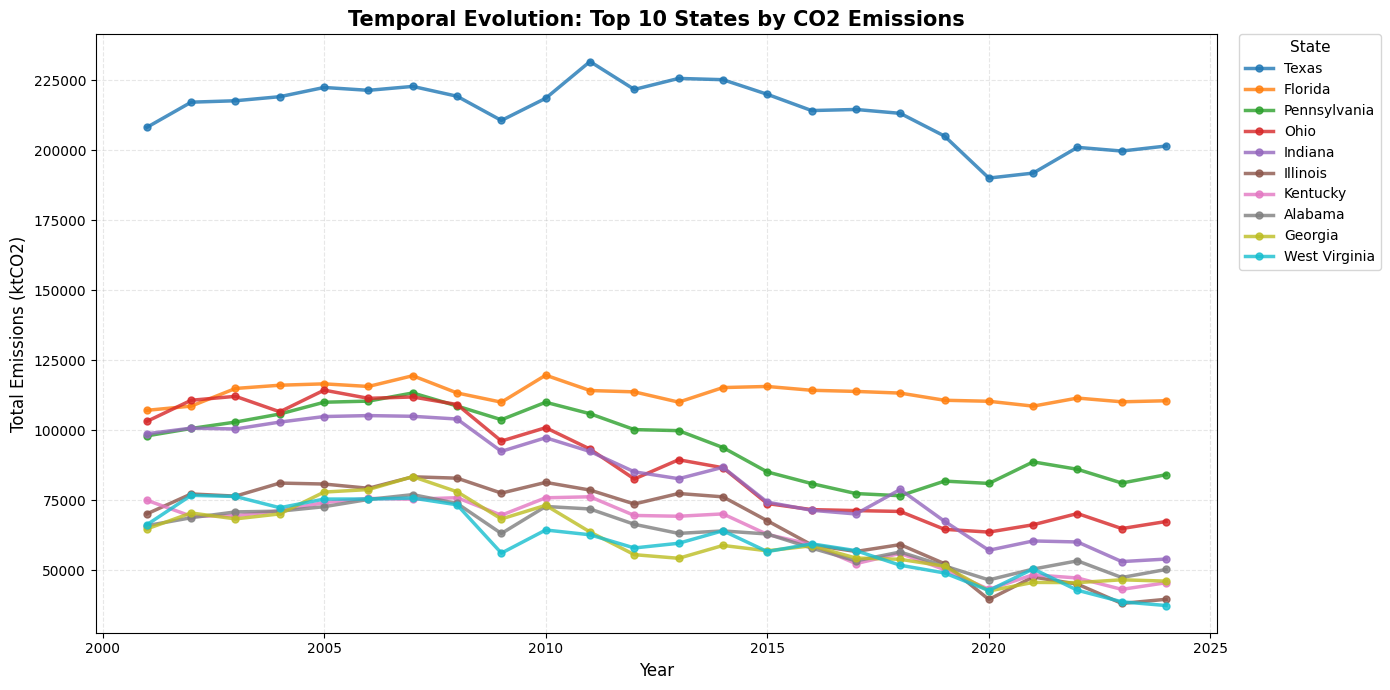

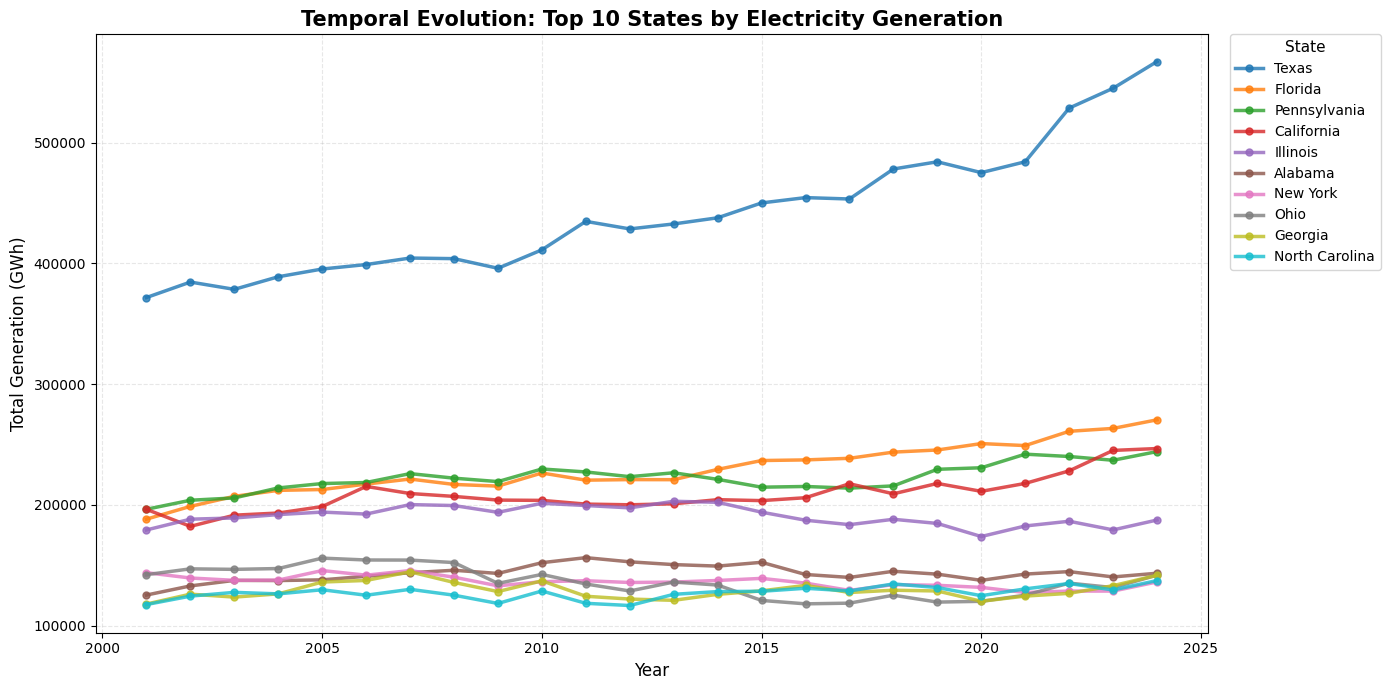

In [123]:
#Grafico 1:

top10_states = annual_emissions.groupby('State')['Total_Emissions_ktCO2'].mean().nlargest(10).index
top10_data = annual_emissions[annual_emissions['State'].isin(top10_states)]

plt.figure(figsize=(14, 7))

colors = plt.cm.tab10(range(10))  

for i, state in enumerate(top10_states):
    state_data = top10_data[top10_data['State'] == state]
    plt.plot(state_data['Year'], state_data['Total_Emissions_ktCO2'], 
             marker='o', markersize=5, linewidth=2.5, 
             label=state, color=colors[i], alpha=0.80) 

plt.title('Temporal Evolution: Top 10 States by CO2 Emissions', 
          fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)

plt.grid(True, alpha=0.3, linestyle='--')

plt.legend(title='State', fontsize=10, title_fontsize=11, 
           bbox_to_anchor=(1.02, 1), loc='upper left', 
           frameon=True, borderaxespad=0)

plt.tight_layout()
plt.show()

#Grafico 2:

generation_data = df_analisi[
    (df_analisi['Category'] == 'Electricity generation') &
    (df_analisi['Subcategory'] == 'Total') &
    (df_analisi['Variable'] == 'Total Generation') &
    (df_analisi['Unit'] == 'GWh')
].copy()


annual_generation = generation_data.groupby(['State', 'Year'])['Value'].sum().reset_index()
annual_generation.rename(columns={'Value': 'Total_Generation_GWh'}, inplace=True)

top10_gen_states = annual_generation.groupby('State')['Total_Generation_GWh'].mean().nlargest(10).index
top10_gen_data = annual_generation[annual_generation['State'].isin(top10_gen_states)]

plt.figure(figsize=(14, 7))

colors = plt.cm.tab10(range(10))

for i, state in enumerate(top10_gen_states):
    state_data = top10_gen_data[top10_gen_data['State'] == state]
    plt.plot(state_data['Year'], state_data['Total_Generation_GWh'], 
             marker='o', markersize=5, linewidth=2.5, 
             label=state, color=colors[i], alpha=0.80)

plt.title('Temporal Evolution: Top 10 States by Electricity Generation', 
          fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Generation (GWh)', fontsize=12)

plt.grid(True, alpha=0.3, linestyle='--')

plt.legend(title='State', fontsize=10, title_fontsize=11, 
           bbox_to_anchor=(1.02, 1), loc='upper left', 
           frameon=True, borderaxespad=0)
plt.tight_layout()
plt.show()

Grafico di correlazione tra generazione di elettricità ed emissioni di CO2

In [124]:
generation_data = df_analisi[
    (df_analisi['Category'] == 'Electricity generation') &
    (df_analisi['Subcategory'] == 'Total') &
    (df_analisi['Variable'] == 'Total Generation') &
    (df_analisi['Unit'] == 'GWh')
].copy()

annual_generation = generation_data.groupby(['State', 'Year'])['Value'].sum().reset_index()
annual_generation.rename(columns={'Value': 'Total_Generation_GWh'}, inplace=True)

efficiency_data = annual_emissions.merge(annual_generation, on=['State', 'Year'])
efficiency_data = efficiency_data.merge(
    annual_intensity[['State', 'Year', 'CO2_Intensity_gCO2_kWh']],
    on=['State', 'Year']
)


all_states = sorted(efficiency_data['State'].unique())
years = sorted(efficiency_data['Year'].unique())
complete_index = pd.MultiIndex.from_product([years, all_states], names=['Year', 'State'])
efficiency_data = efficiency_data.set_index(['Year', 'State']).reindex(complete_index).reset_index()

efficiency_data['Total_Generation_GWh'] = efficiency_data['Total_Generation_GWh'].fillna(0)
efficiency_data['Total_Emissions_ktCO2'] = efficiency_data['Total_Emissions_ktCO2'].fillna(0)
efficiency_data['CO2_Intensity_gCO2_kWh'] = efficiency_data['CO2_Intensity_gCO2_kWh'].fillna(0)

state_code_map = annual_emissions[['State', 'State code']].drop_duplicates().set_index('State')['State code'].to_dict()
efficiency_data['State code'] = efficiency_data['State'].map(state_code_map)

max_emissions_global = efficiency_data['Total_Emissions_ktCO2'].max()
min_size = 12
size_scale = 48

efficiency_data['Size'] = np.where(
    efficiency_data['Total_Emissions_ktCO2'] > 0,
    min_size + (efficiency_data['Total_Emissions_ktCO2'] / max_emissions_global) * size_scale,
    0
)

first_year = years[0]
first_year_data = efficiency_data[efficiency_data['Year'] == first_year].copy()

top10_first_data = first_year_data[first_year_data['Total_Generation_GWh'] > 0].nlargest(10, 'Total_Generation_GWh')
top10_first = top10_first_data['State'].tolist()

legend_text_first = "Top 10 Generators of Electricity:<br>"
for state in top10_first:
    state_code = first_year_data[first_year_data['State'] == state]['State code'].iloc[0]
    legend_text_first += f"{state_code} - {state}<br>"

# Crea annotations per le etichette Top 10
annotations_first = []
for _, row in top10_first_data.iterrows():
    annotations_first.append(
        dict(
            x=row['Total_Generation_GWh'],
            y=row['Total_Emissions_ktCO2'],
            text=row['State code'],
            showarrow=False,
            font=dict(size=10, color='black', family='Arial Black'),
            xref='x',
            yref='y',
            xanchor='center',
            yanchor='middle'
        )
    )

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=first_year_data['Total_Generation_GWh'],
    y=first_year_data['Total_Emissions_ktCO2'],
    mode='markers',  
    marker=dict(
        size=first_year_data['Size'],
        sizemode='diameter',
        color=first_year_data['CO2_Intensity_gCO2_kWh'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(
            title="CO2 Intensity<br>(gCO2/kWh)",
            thickness=15,
            len=0.7
        ),
        line=dict(width=0.5, color='white')
    ),
    hovertemplate='<b>%{customdata[0]}</b><br>' +
                  'Generation: %{x:,.0f} GWh<br>' +
                  'Emissions: %{y:,.0f} ktCO2<br>' +
                  'Intensity: %{customdata[1]:.1f} gCO2/kWh<extra></extra>',
    customdata=np.column_stack([first_year_data['State'], first_year_data['CO2_Intensity_gCO2_kWh']]),
    showlegend=False
))


frames = []
for year in years:
    year_data = efficiency_data[efficiency_data['Year'] == year].copy()
    
    top10_year_data = year_data[year_data['Total_Generation_GWh'] > 0].nlargest(10, 'Total_Generation_GWh')
    top10_year = top10_year_data['State'].tolist()
    
    legend_text_year = "Top 10 Generators:<br>"
    for state in top10_year:
        state_code = year_data[year_data['State'] == state]['State code'].iloc[0]
        legend_text_year += f"{state_code} - {state}<br>"
  
    annotations_year = [
        dict(
            text=legend_text_year,
            xref='paper',
            yref='paper',
            x=0.02,
            y=0.98,
            xanchor='left',
            yanchor='top',
            showarrow=False,
            bgcolor='rgba(255, 255, 255, 0.9)',
            bordercolor='black',
            borderwidth=1,
            borderpad=10,
            font=dict(size=9, family='Arial')
        )
    ]
    
    for _, row in top10_year_data.iterrows():
        annotations_year.append(
            dict(
                x=row['Total_Generation_GWh'],
                y=row['Total_Emissions_ktCO2'],
                text=row['State code'],
                showarrow=False,
                font=dict(size=10, color='black', family='Arial Black'),
                xref='x',
                yref='y',
                xanchor='center',
                yanchor='middle'
            )
        )
    
    frame = go.Frame(
        name=str(year),
        data=[go.Scatter(
            x=year_data['Total_Generation_GWh'],
            y=year_data['Total_Emissions_ktCO2'],
            mode='markers',  # SOLO markers
            marker=dict(
                size=year_data['Size'],
                sizemode='diameter',
                color=year_data['CO2_Intensity_gCO2_kWh'],
                colorscale='RdYlGn_r',
                showscale=True,
                line=dict(width=0.5, color='white')
            ),
            hovertemplate='<b>%{customdata[0]}</b><br>' +
                          'Generation: %{x:,.0f} GWh<br>' +
                          'Emissions: %{y:,.0f} ktCO2<br>' +
                          'Intensity: %{customdata[1]:.1f} gCO2/kWh<extra></extra>',
            customdata=np.column_stack([year_data['State'], year_data['CO2_Intensity_gCO2_kWh']])
        )],
        layout=go.Layout(annotations=annotations_year)
    )
    frames.append(frame)

fig.frames = frames

initial_annotations = [
    dict(
        text=legend_text_first,
        xref='paper',
        yref='paper',
        x=0.02,
        y=0.98,
        xanchor='left',
        yanchor='top',
        showarrow=False,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='black',
        borderwidth=1,
        borderpad=10,
        font=dict(size=9, family='Arial')
    )
] + annotations_first

fig.update_layout(
    title='State Comparison: Power Generation, CO2 Emissions & Efficiency',
    xaxis=dict(
        title='Total Generation (GWh)',
        range=[0, efficiency_data['Total_Generation_GWh'].max() * 1.05]
    ),
    yaxis=dict(
        title='Total Emissions (ktCO2)',
        range=[0, efficiency_data['Total_Emissions_ktCO2'].max() * 1.05]
    ),
    height=700,
    font=dict(size=12),
    title_font_size=16,
    title_x=0.5,
    title_font_family='Arial',
    title_font_weight='bold',
    annotations=initial_annotations,
    sliders=[
        dict(
            active=0,
            steps=[
                dict(
                    label=str(year),
                    method='animate',
                    args=[
                        [str(year)],
                        dict(
                            frame=dict(duration=0, redraw=True),
                            mode='immediate',
                            transition=dict(duration=0)
                        )
                    ]
                )
                for year in years
            ],
            x=0.1,
            y=0,
            len=0.85,
            xanchor='left',
            yanchor='top'
        )
    ]
)

fig.show()


Grafico a torta per vedere il mix di produzione di elettricità negli USA

In [125]:
df_us_total = pd.read_csv('../data/raw/us_monthly_electricity.csv')
df_us_total['Date'] = pd.to_datetime(df_us_total['Date'])
df_us_total['Year'] = df_us_total['Date'].dt.year

df_us_total = df_us_total[
    (df_us_total['State'] == 'US Total') &
    (df_us_total['Year'] < 2025)
].copy()

energy_mix_us = df_us_total[
    (df_us_total['Category'] == 'Electricity generation') &
    (df_us_total['Subcategory'] == 'Fuel') &
    (df_us_total['Unit'] == 'GWh')
].copy()

energy_mix_annual = energy_mix_us.groupby(['Year', 'Variable'])['Value'].sum().reset_index()

color_map = {
    'Coal': '#8B4513',
    'Gas': "#FF8400",
    'Nuclear': '#9370DB',
    'Hydro': '#4169E1',
    'Wind': "#AEE9E9",
    'Solar': "#F1DB5C",
    'Bioenergy': '#228B22',
    'Other Renewables': '#98FB98',
    'Other Fossil': '#A9A9A9'
}

first_year = energy_mix_annual['Year'].min()
first_year_data = energy_mix_annual[energy_mix_annual['Year'] == first_year].copy()
first_year_data = first_year_data.sort_values('Value', ascending=False).reset_index(drop=True)

total_first = first_year_data['Value'].sum()
text_first = []
for idx, row in first_year_data.iterrows():
    if idx < 5:
        percentage = (row['Value'] / total_first) * 100
        text_first.append(f"{percentage:.1f}%")
    else:
        text_first.append("")


fig = px.pie(
    first_year_data,
    values='Value',
    names='Variable',
    title='US Energy Mix, Evolution in the Years',
    color='Variable',
    color_discrete_map=color_map,
    hole=0.3
)

fig.update_traces(
    text=text_first,
    textinfo='text',
    textposition='inside',
    textfont=dict(size=14, color='white', family='Arial Black'),
    hovertemplate='<b>%{label}</b><br>Generation: %{value:,.0f} GWh<br>Percentage: %{percent}<extra></extra>',
    sort=False  
)

frames = []
for year in sorted(energy_mix_annual['Year'].unique()):
    year_data = energy_mix_annual[energy_mix_annual['Year'] == year].copy()

    year_data = year_data.sort_values('Value', ascending=False).reset_index(drop=True)
  
    total_value = year_data['Value'].sum()
    text_list = []
    for idx, row in year_data.iterrows():
        if idx < 5:
            percentage = (row['Value'] / total_value) * 100
            text_list.append(f"{percentage:.1f}%")
        else:
            text_list.append("")
    
    colors = [color_map.get(fuel, '#CCCCCC') for fuel in year_data['Variable']]
    
    frame = dict(
        data=[dict(
            type='pie',
            values=year_data['Value'].tolist(),
            labels=year_data['Variable'].tolist(),
            text=text_list,
            textinfo='text',
            textposition='inside',
            textfont=dict(size=14, color='white', family='Arial Black'),
            hole=0.3,
            marker=dict(colors=colors),
            sort=False, 
            hovertemplate='<b>%{label}</b><br>Generation: %{value:,.0f} GWh<br>Percentage: %{percent}<extra></extra>'
        )],
        name=str(year)
    )
    frames.append(frame)

fig.frames = frames


fig.update_layout(
    height=700,
    font=dict(size=12),
    title_font_size=18,
    title_x=0.5,
    legend=dict(
        traceorder='normal'  
    ),
    sliders=[
        dict(
            active=0,
            steps=[
                dict(
                    label=str(year),
                    method='animate',
                    args=[
                        [str(year)],
                        dict(
                            frame=dict(duration=0, redraw=True),
                            mode='immediate'
                        )
                    ]
                )
                for year in sorted(energy_mix_annual['Year'].unique())
            ],
            x=0.1,
            y=0,
            len=0.85,
            xanchor='left',
            yanchor='top'
        )
    ]
)

fig.show()


Analisi sulla generazione di elettricità

                Value
Date                 
2001-01-01  331770.42
2001-02-01  282305.52
2001-03-01  300016.76
2001-04-01  277521.79
2001-05-01  299747.31


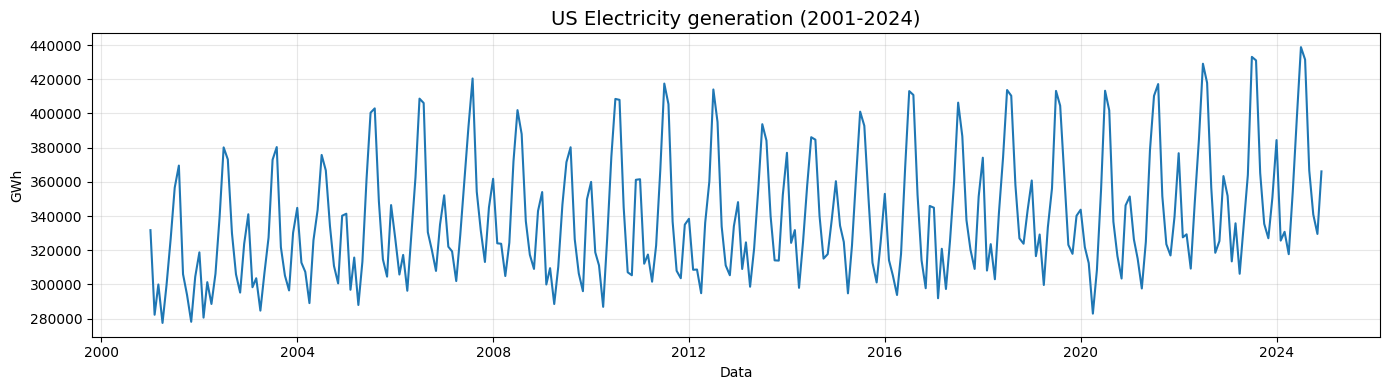

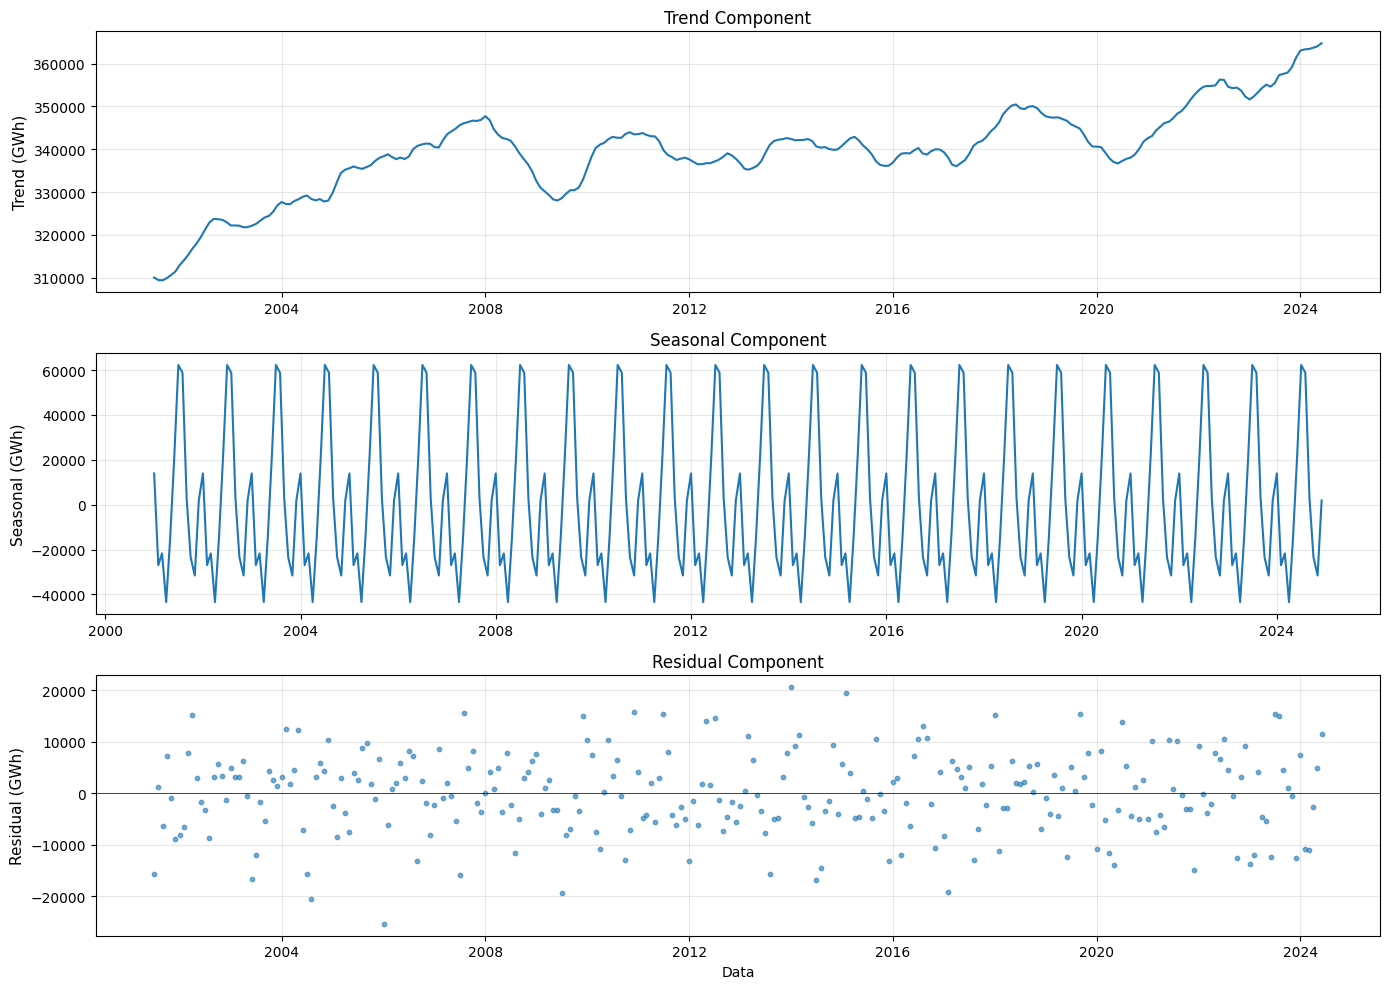

In [126]:
df = pd.read_csv("../data/raw/us_monthly_electricity.csv")
df['Date'] = pd.to_datetime(df['Date'])

mask = (
    (df['State'] == 'US Total') & 
    (df['Category'] == 'Electricity generation') &
    (df['Variable'] == 'Total Generation') &
    (df['Unit'] == 'GWh')
)

ts_data = df.loc[mask, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_data = ts_data[ts_data.index.year <= 2024]
ts_data = ts_data.asfreq('MS') 

decomposition = seasonal_decompose(ts_data['Value'], model='additive')
print(ts_data.head())

# Grafico 1: Serie originale
plt.figure(figsize=(14, 4))
plt.plot(ts_data.index, ts_data['Value'], linewidth=1.5)
plt.title('US Electricity generation (2001-2024)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('GWh')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, linewidth=1.5)
axes[0].set_ylabel('Trend (GWh)', fontsize=11)
axes[0].set_title('Trend Component', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, linewidth=1.5)
axes[1].set_ylabel('Seasonal (GWh)', fontsize=11)
axes[1].set_title('Seasonal Component', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Residual (con scatter plot)
axes[2].scatter(decomposition.resid.index, decomposition.resid, s=10, alpha=0.6)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_ylabel('Residual (GWh)', fontsize=11)
axes[2].set_xlabel('Data')
axes[2].set_title('Residual Component', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


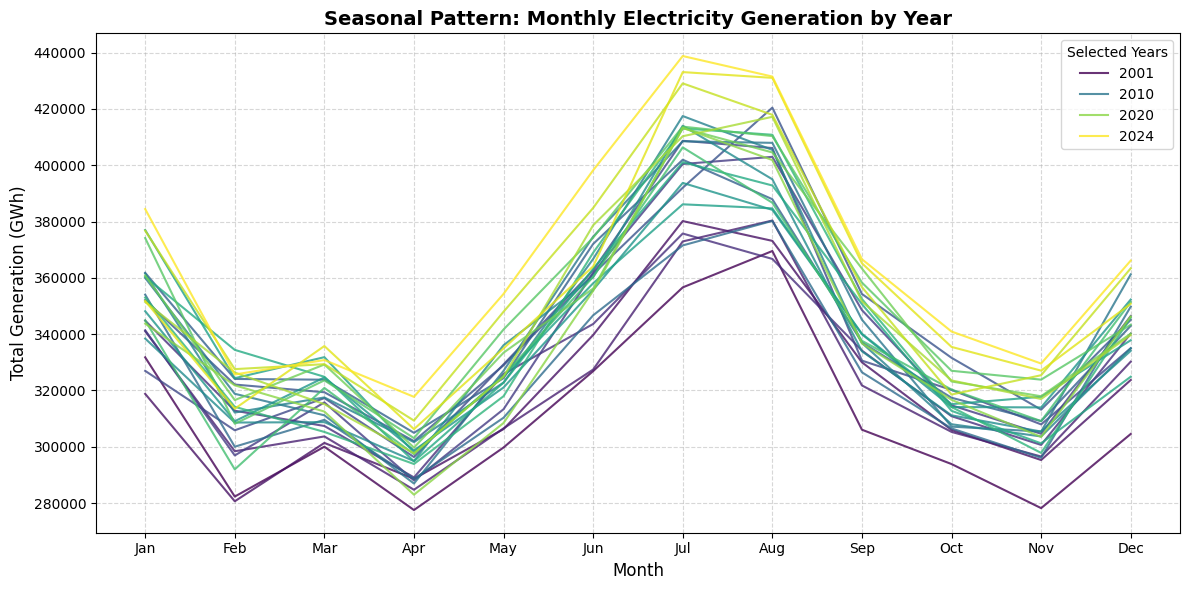

In [127]:
plt.figure(figsize=(12, 6))

ts_data['Year'] = ts_data.index.year
ts_data['Month'] = ts_data.index.month

pivot_df = ts_data.pivot(index='Month', columns='Year', values='Value')

colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_df.columns)))
for i, year in enumerate(pivot_df.columns):
    label = year if year in [2001, 2010, 2020, 2024] else ""
    plt.plot(pivot_df.index, pivot_df[year], color=colors[i], marker='', linewidth=1.5, alpha=0.8, label=label)

plt.title('Seasonal Pattern: Monthly Electricity Generation by Year', fontsize=14, fontweight='bold')
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Selected Years', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

ts_data = ts_data.drop(columns=['Year', 'Month'])



--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -2.1335757884715347
p-value: 0.23122962883667625
Critical Values:
	1%: -3.45453261164607
	5%: -2.8721859575020017
	10%: -2.572442854861866
Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.


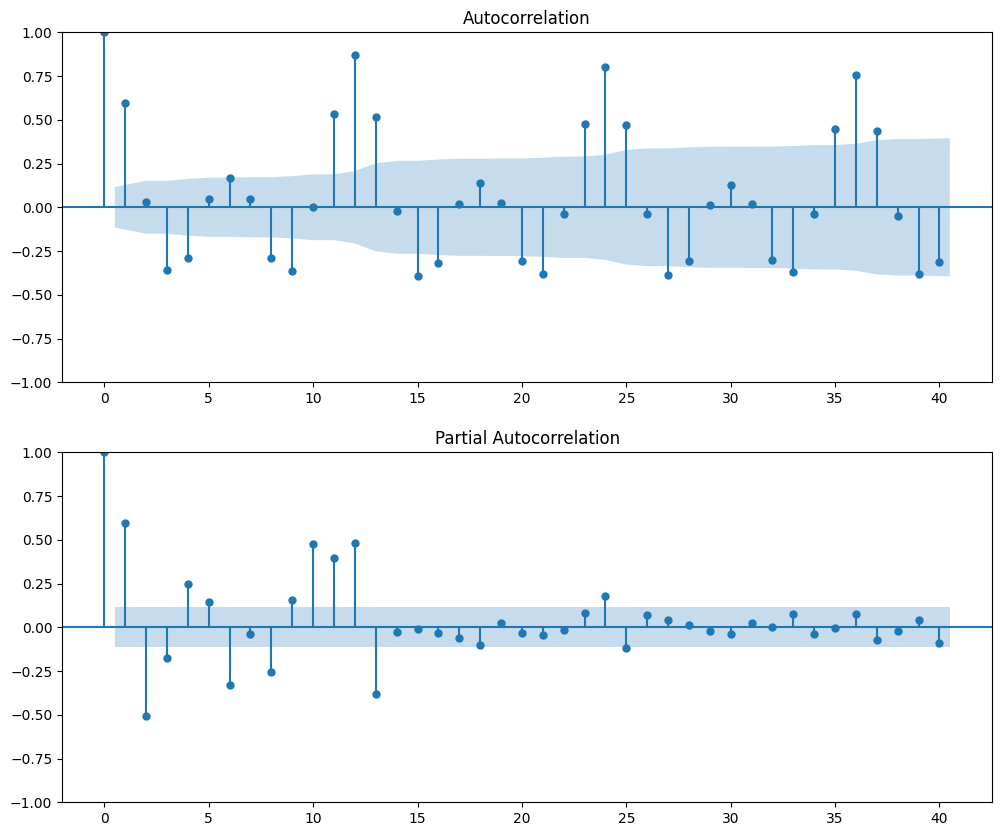

In [128]:
print("\n--- Augmented Dickey-Fuller Test Results ---")
result = adfuller(ts_data['Value'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# 3. ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_data['Value'], ax=ax1, lags=40);
plot_pacf(ts_data['Value'], ax=ax2, lags=40);


ADF Statistic: -5.122649669529774
p-value: 1.2620984597081788e-05
Critical Values:
	1%: -3.4554613060274972
	5%: -2.8725931472675046
	10%: -2.5726600403359887
Result: The series is Stationary (Reject Null Hypothesis)


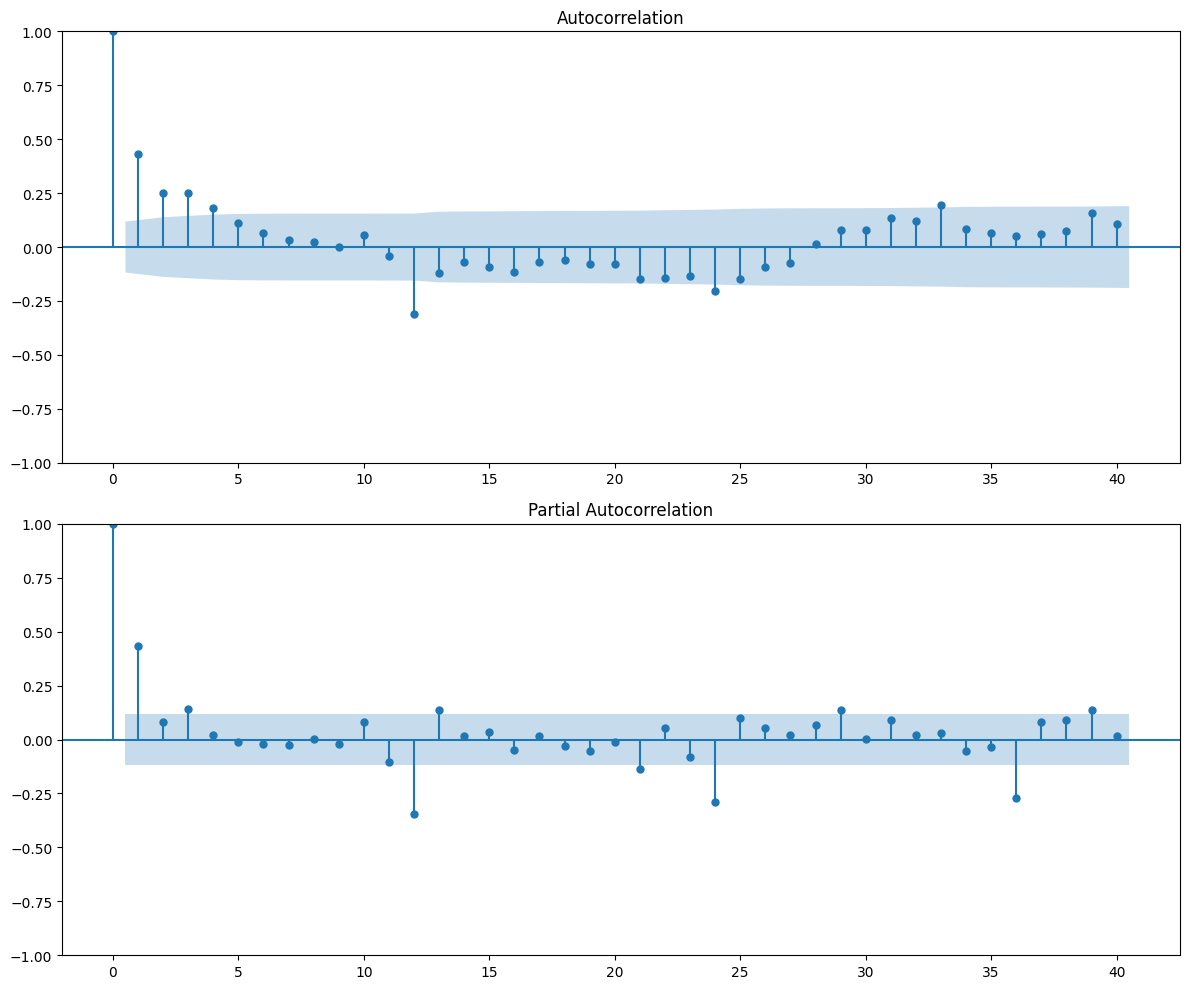

               Value
Date                
2002-01-01 -12974.00
2002-02-01  -1679.02
2002-03-01   1344.63
2002-04-01  11101.43
2002-05-01   6529.59


In [129]:
ts_seasonal_diff = ts_data.copy()
ts_seasonal_diff['Value'] = ts_data['Value'].diff(12)
ts_seasonal_diff = ts_seasonal_diff.dropna()

# Ora puoi accedere con ts_seasonal_diff['Value']
adf_test_final = adfuller(ts_seasonal_diff['Value'])
print(f'ADF Statistic: {adf_test_final[0]}')
print(f'p-value: {adf_test_final[1]}')
print('Critical Values:')
for key, value in adf_test_final[4].items():
    print(f'\t{key}: {value}')

if adf_test_final[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_seasonal_diff['Value'], ax=ax1, lags=40)
plot_pacf(ts_seasonal_diff['Value'], ax=ax2, lags=40)
plt.tight_layout()
plt.show()

print(ts_seasonal_diff.head())

Training data: dal 2001-01-01 al 2022-12-01
Test data: dal 2023-01-01 al 2024-12-01
Addestramento del modello in corso...
Modello addestrato!
                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  264
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood               -2558.112
Date:                            Tue, 16 Dec 2025   AIC                           5122.223
Time:                                    17:05:49   BIC                           5132.653
Sample:                                01-01-2001   HQIC                          5126.426
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

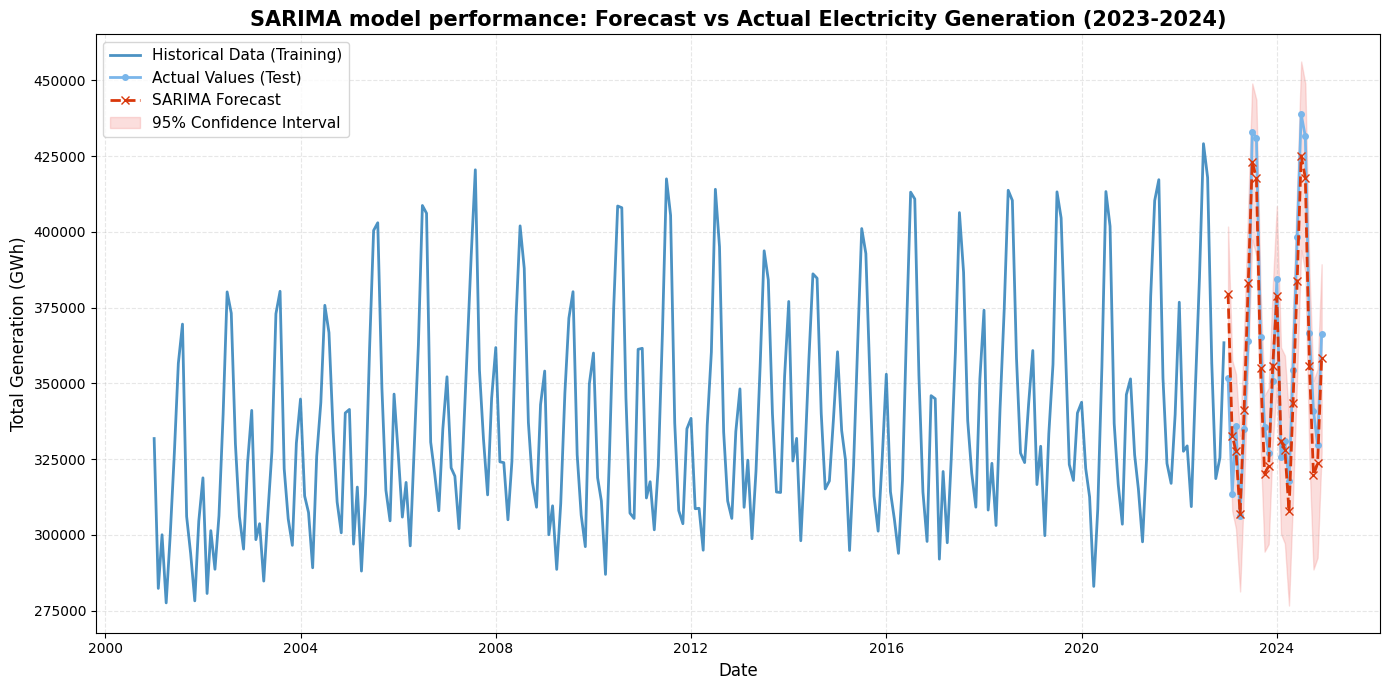

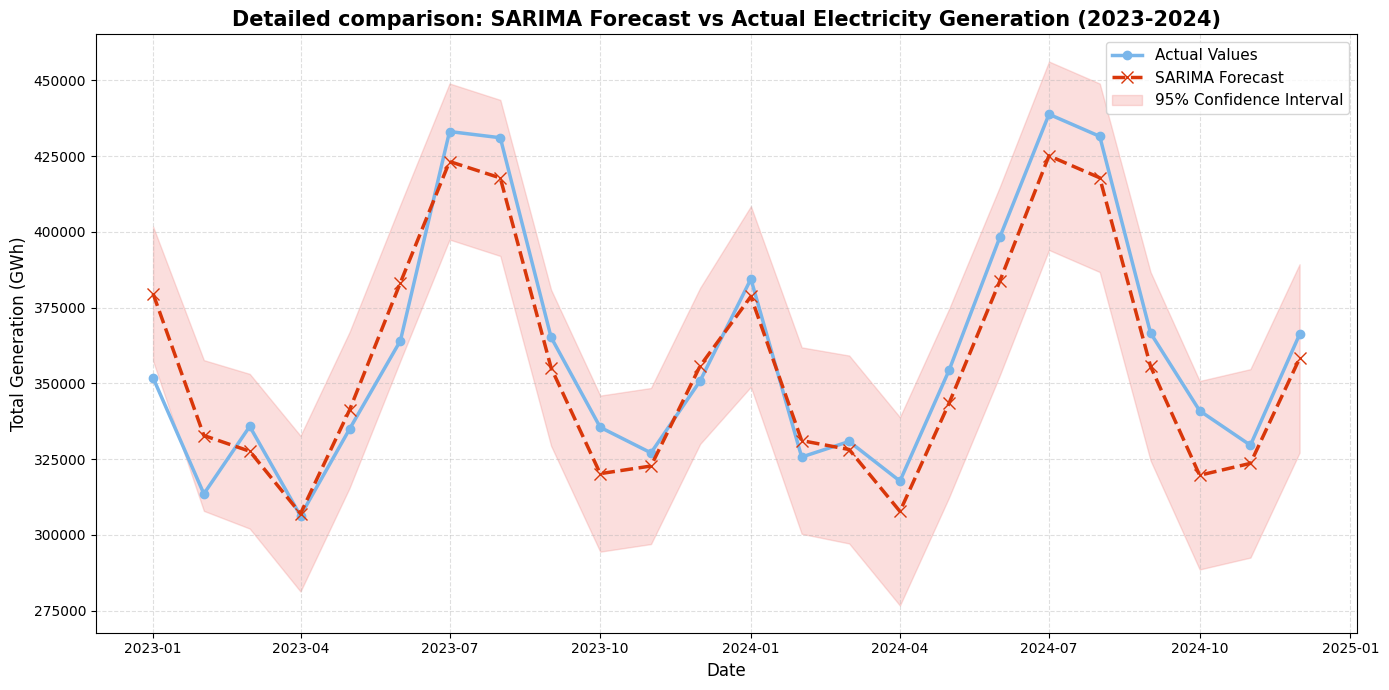


Errore Medio Assoluto Percentuale (MAPE): 3.02%
Significa che il modello sbaglia in media del 3.02%


In [130]:
train_data = ts_data.iloc[:-24]
test_data = ts_data.iloc[-24:]

print(f"Training data: dal {train_data.index.min().date()} al {train_data.index.max().date()}")
print(f"Test data: dal {test_data.index.min().date()} al {test_data.index.max().date()}")

my_order = (1, 0, 0)              # (p, d, q) - Parte non stagionale
my_seasonal_order = (1, 1, 0, 12) # (P, D, Q, m) - Parte stagionale (m=12 mesi)

model = SARIMAX(train_data['Value'], 
                order=my_order, 
                seasonal_order=my_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)


print("Addestramento del modello in corso...")
model_fit = model.fit(disp=False)
print("Modello addestrato!")
print(model_fit.summary())

forecast = model_fit.get_forecast(steps=len(test_data))
predicted_values = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(14, 7))

# Dati di training - blu pastello
plt.plot(train_data.index, train_data['Value'], 
         label='Historical Data (Training)', linewidth=2.0, alpha=0.8) 

# Dati reali test - verde chiaro/teal
plt.plot(test_data.index, test_data['Value'], 
         label='Actual Values (Test)', 
         color="#7AB6EA", linewidth=2.0, marker='o', markersize=4)  # Azzurro/Teal

# Previsioni - arancione/corallo
plt.plot(test_data.index, predicted_values, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='x', markersize=6)  # Arancione

# Intervallo di confidenza - arancione chiaro
plt.fill_between(test_data.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')  # Arancione chiaro

plt.title('SARIMA model performance: Forecast vs Actual Electricity Generation (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#Grafico 2: Comparazione dettagliata

plt.figure(figsize=(14, 7))

# Valori reali - azzurro teal
plt.plot(test_data.index, test_data['Value'], 
         label='Actual Values', 
         color="#7AB6EA", linewidth=2.5, marker='o', markersize=6)

# Previsioni - rosso/arancione
plt.plot(test_data.index, predicted_values, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='x', markersize=8)

# Intervallo di confidenza - rosa/corallo
plt.fill_between(test_data.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('Detailed comparison: SARIMA Forecast vs Actual Electricity Generation (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

mape = mean_absolute_percentage_error(test_data['Value'], predicted_values)
print(f"\nErrore Medio Assoluto Percentuale (MAPE): {mape:.2%}")
print(f"Significa che il modello sbaglia in media del {mape:.2%}")

Si riaddestra usando tutti i dati stavolta

Training model on full dataset...
Model trained successfully!

=== Future Forecasts ===
            Predicted_Value    Lower_Bound    Upper_Bound
Date                                                     
2025-01-01    377133.473028  354196.706943  400070.239113
2025-02-01    323572.236378  298000.351299  349144.121457
2025-03-01    333971.262709  307799.152013  360143.373405
2025-04-01    313960.401514  287644.520382  340276.282647
2025-05-01    347201.524796  320850.830017  373552.219576
2025-06-01    385301.958034  358942.811479  411661.104589
2025-07-01    436704.387101  410343.187415  463065.586786
2025-08-01    431380.301176  405018.602663  457741.999689
2025-09-01    366092.904947  339731.085235  392454.724660
2025-10-01    338852.730976  312490.881816  365214.580136
2025-11-01    328602.354659  302240.498343  354964.210974
2025-12-01    360268.930087  333907.072033  386630.788140
2026-01-01    379935.066276  350011.770526  409858.362026
2026-02-01    324376.079608  293649.727575

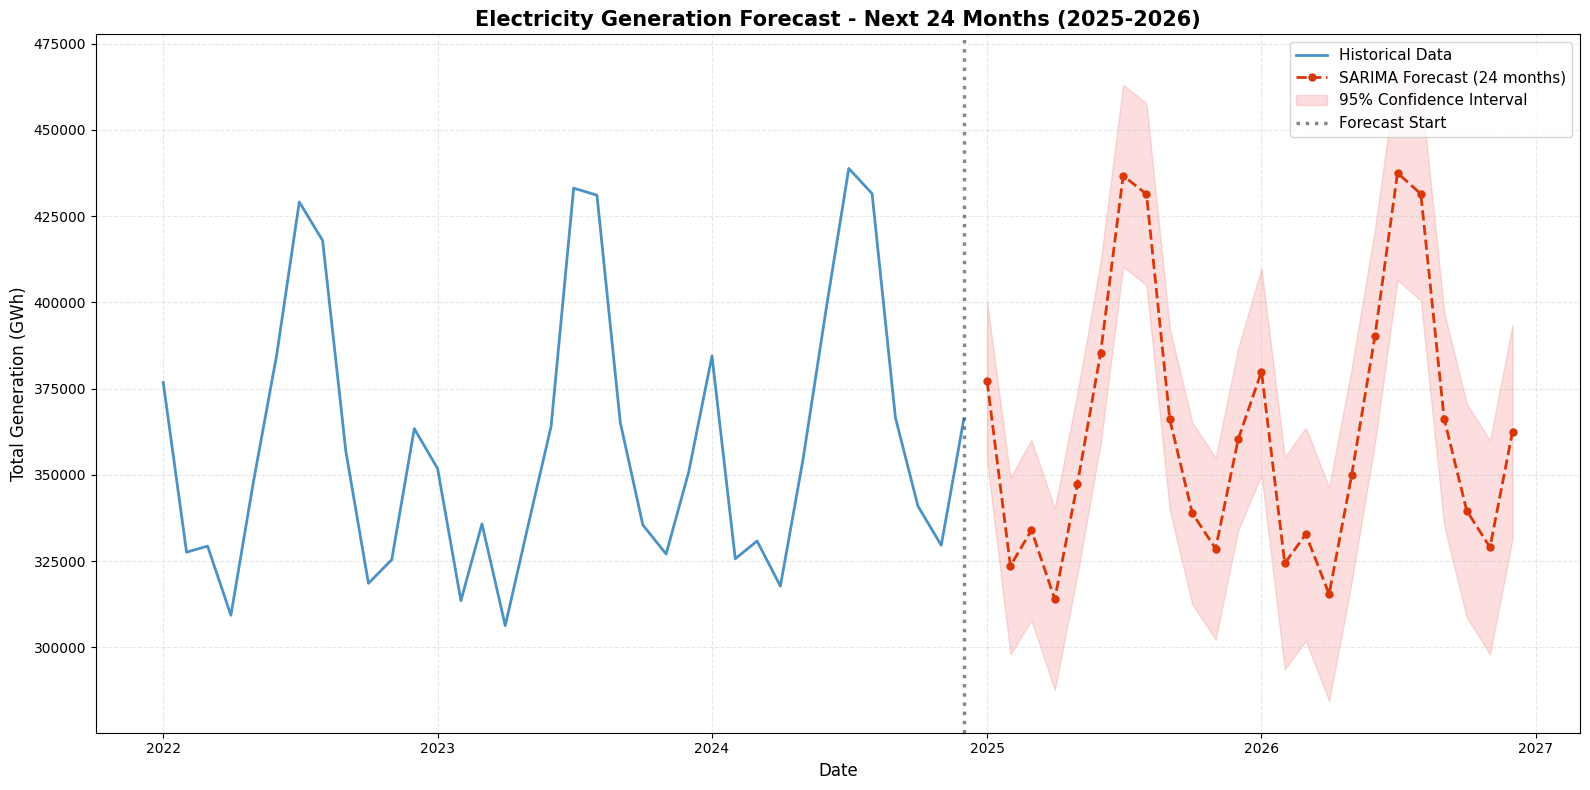

In [131]:
full_data = ts_data['Value']

my_order = (1, 0, 0)
my_seasonal_order = (1, 1, 0, 12)

model_full = SARIMAX(full_data, 
                     order=my_order, 
                     seasonal_order=my_seasonal_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False)

print("Training model on full dataset...")
model_full_fit = model_full.fit(disp=False)
print("Model trained successfully!")

n_months = 24  # Modify to forecast more or fewer months

forecast_future = model_full_fit.get_forecast(steps=n_months)
predicted_future = forecast_future.predicted_mean
conf_int_future = forecast_future.conf_int()

last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                             periods=n_months, 
                             freq='MS') 

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Value': predicted_future.values,
    'Lower_Bound': conf_int_future.iloc[:, 0].values,
    'Upper_Bound': conf_int_future.iloc[:, 1].values
})
forecast_df.set_index('Date', inplace=True)

print("\n=== Future Forecasts ===")
print(forecast_df)

plt.figure(figsize=(16, 8))

historical = ts_data.iloc[-36:]
plt.plot(historical.index, historical['Value'], 
         label='Historical Data', linewidth=2.0, alpha=0.8)

plt.plot(future_dates, predicted_future, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='o', markersize=5)

plt.fill_between(future_dates, 
                 conf_int_future.iloc[:, 0], 
                 conf_int_future.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.axvline(x=ts_data.index[-1], color="#4A5866", 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title(f'Electricity Generation Forecast - Next {n_months} Months (2025-2026)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


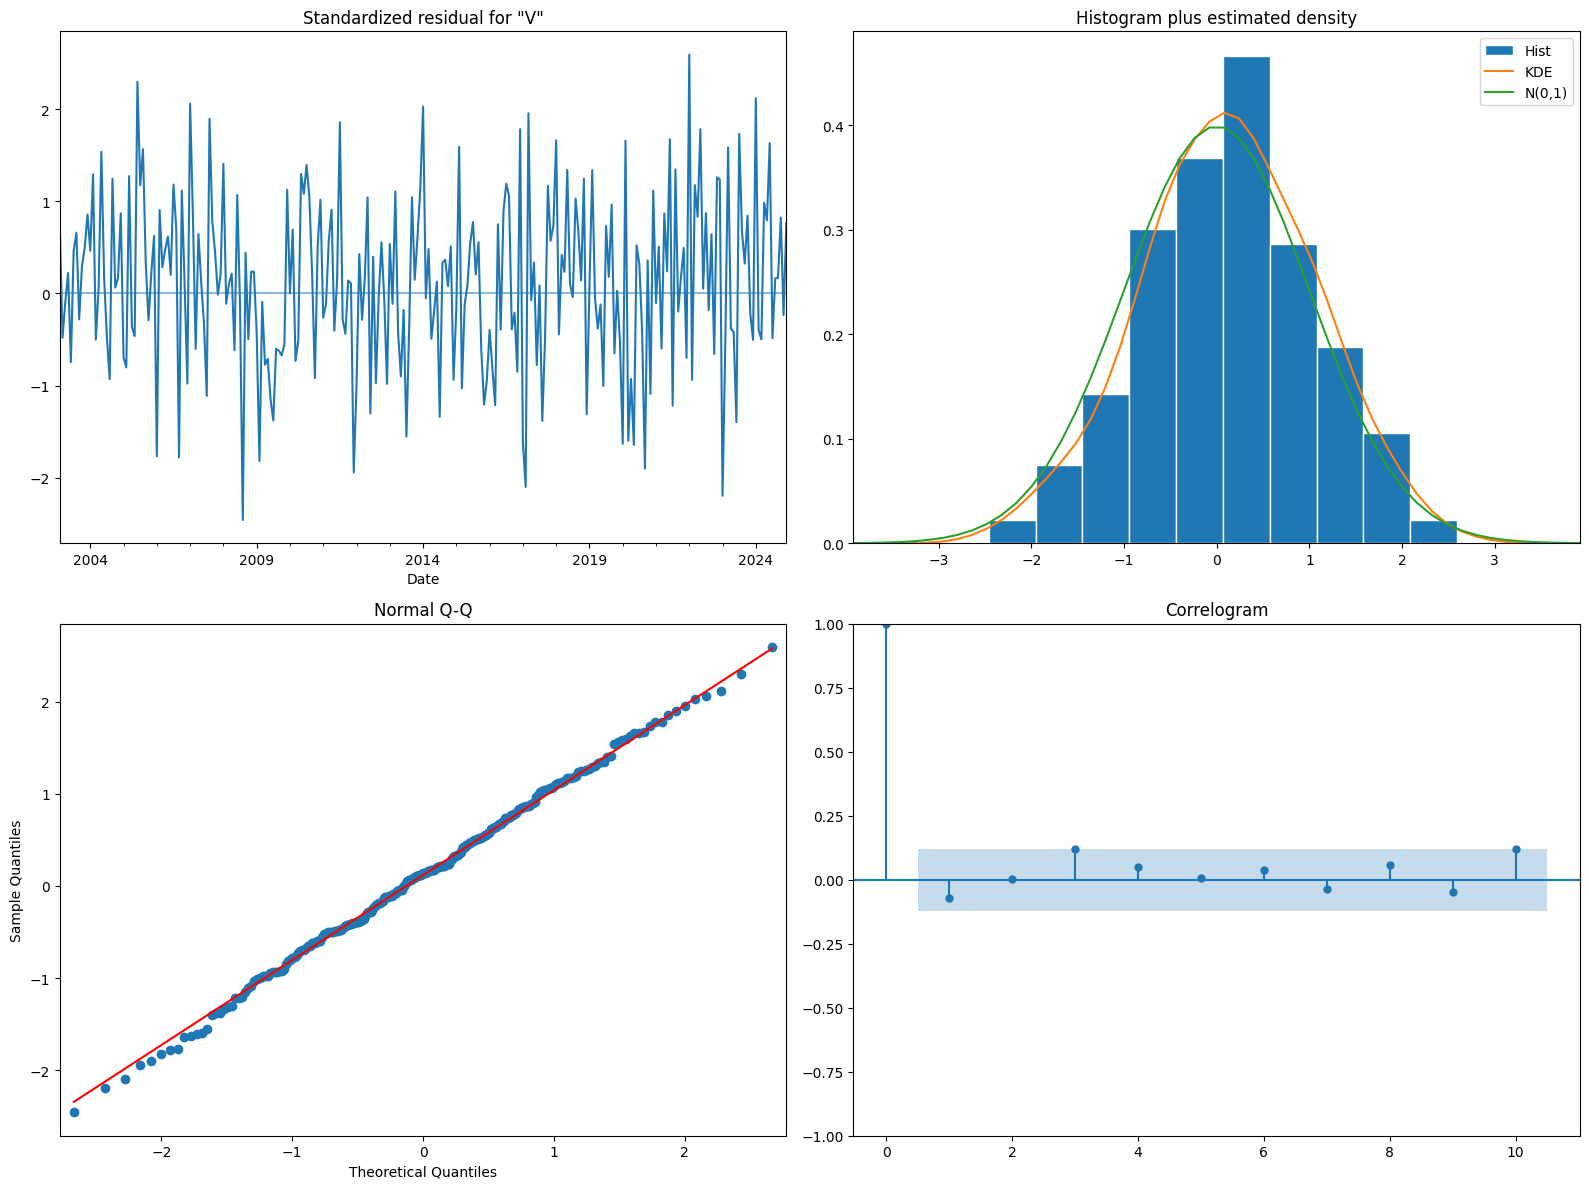

In [132]:
# Diagnostica completa del modello
fig = model_full_fit.plot_diagnostics(figsize=(16, 12))
plt.tight_layout()
plt.show()


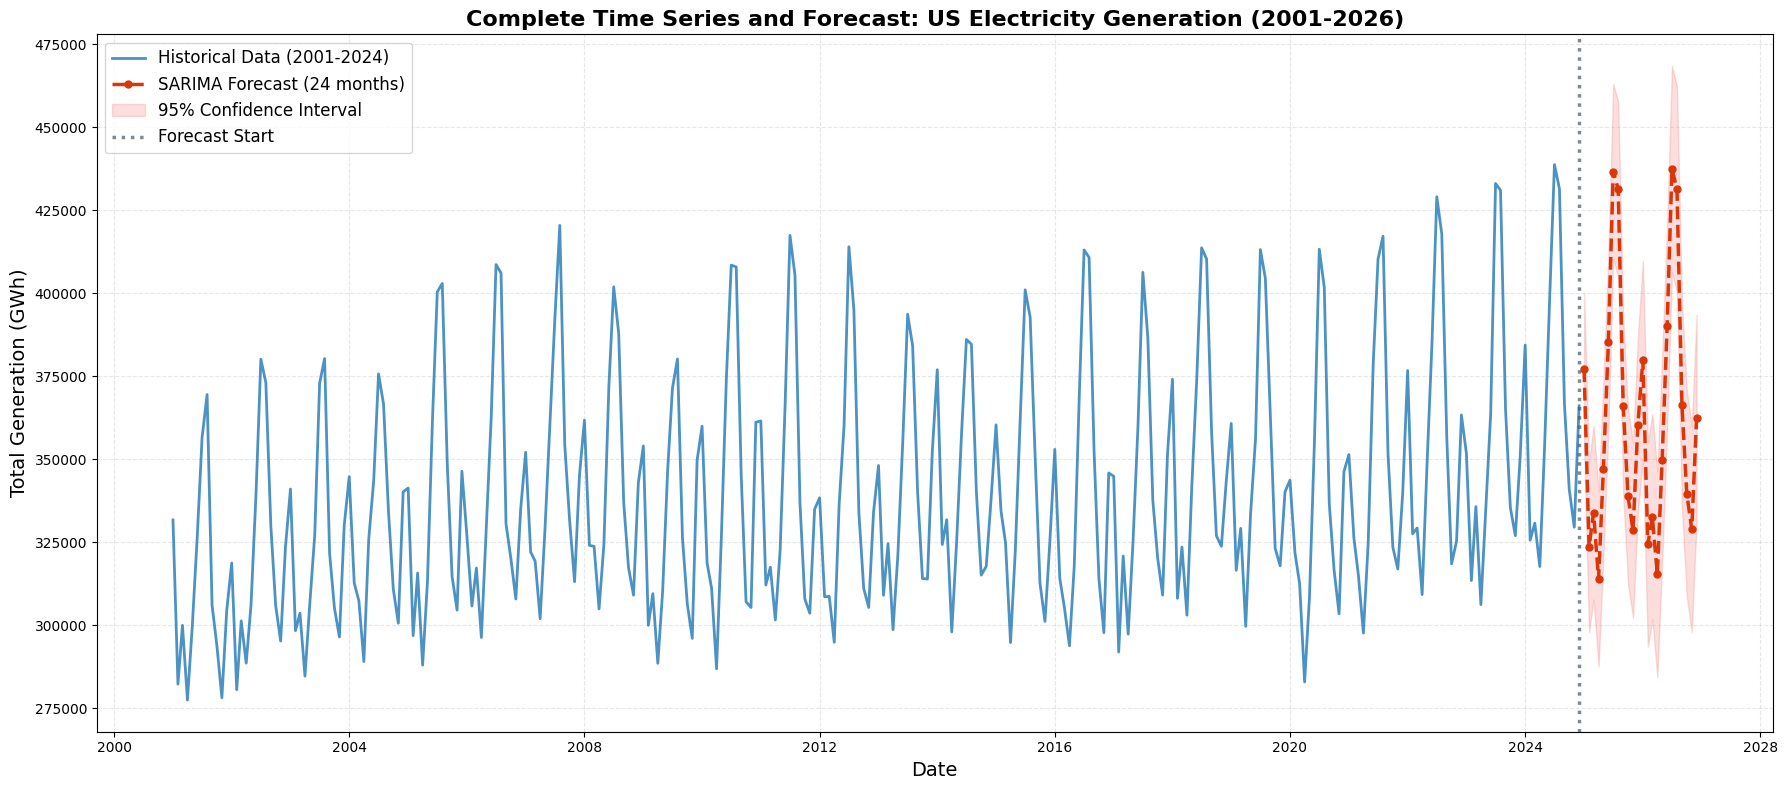

In [133]:
# Grafico 2: Visualizzazione completa serie storica + previsioni
plt.figure(figsize=(18, 8))

plt.plot(ts_data.index, ts_data['Value'], 
         label='Historical Data (2001-2024)', linewidth=2.0, alpha=0.8)

plt.plot(future_dates, predicted_future, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='o', markersize=5)

plt.fill_between(future_dates, 
                 conf_int_future.iloc[:, 0], 
                 conf_int_future.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, label='95% Confidence Interval')

plt.axvline(x=ts_data.index[-1], color='#4A5866', 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title('Complete Time Series and Forecast: US Electricity Generation (2001-2026)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Generation (GWh)', fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Analisi sulle emissioni totali

                Value
Date                 
2001-01-01  181782.37
2001-02-01  151267.55
2001-03-01  160139.01
2001-04-01  148197.66
2001-05-01  159395.30


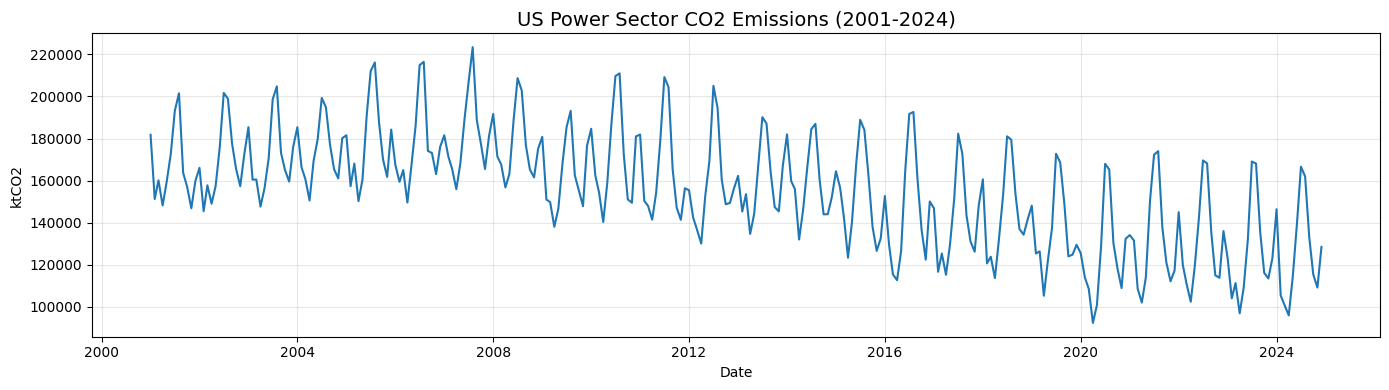

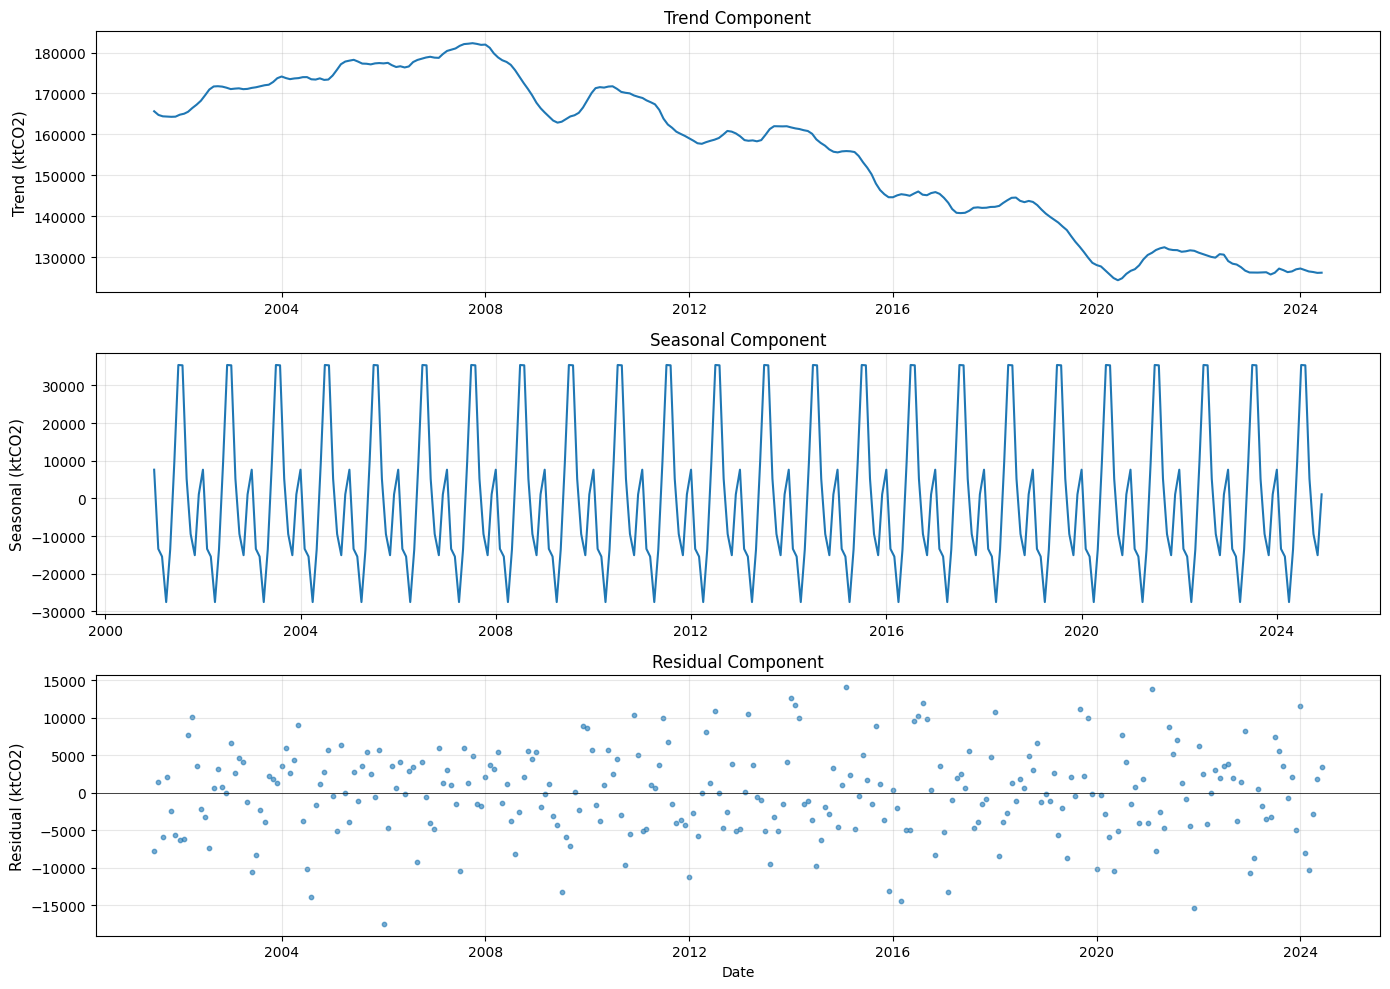

In [134]:
df_emissions = pd.read_csv("../data/raw/us_monthly_electricity.csv")
df_emissions['Date'] = pd.to_datetime(df_emissions['Date'])

mask_emissions = (
    (df_emissions['State'] == 'US Total') & 
    (df_emissions['Category'] == 'Power sector emissions') &
    (df_emissions['Variable'] == 'Total emissions') &
    (df_emissions['Unit'] == 'ktCO2')
)

ts_emissions = df_emissions.loc[mask_emissions, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_emissions = ts_emissions[ts_emissions.index.year <= 2024]
ts_emissions = ts_emissions.asfreq('MS')

decomposition_emissions = seasonal_decompose(ts_emissions['Value'], model='additive')
print(ts_emissions.head())

# Grafico 1: Serie originale
plt.figure(figsize=(14, 4))
plt.plot(ts_emissions.index, ts_emissions['Value'], linewidth=1.5)
plt.title('US Power Sector CO2 Emissions (2001-2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('ktCO2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Grafico 2: Componenti della decomposizione
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition_emissions.trend, linewidth=1.5)
axes[0].set_ylabel('Trend (ktCO2)', fontsize=11)
axes[0].set_title('Trend Component', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Seasonal
axes[1].plot(decomposition_emissions.seasonal, linewidth=1.5)
axes[1].set_ylabel('Seasonal (ktCO2)', fontsize=11)
axes[1].set_title('Seasonal Component', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Residual (con scatter plot)
axes[2].scatter(decomposition_emissions.resid.index, decomposition_emissions.resid, s=10, alpha=0.6)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_ylabel('Residual (ktCO2)', fontsize=11)
axes[2].set_xlabel('Date')
axes[2].set_title('Residual Component', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


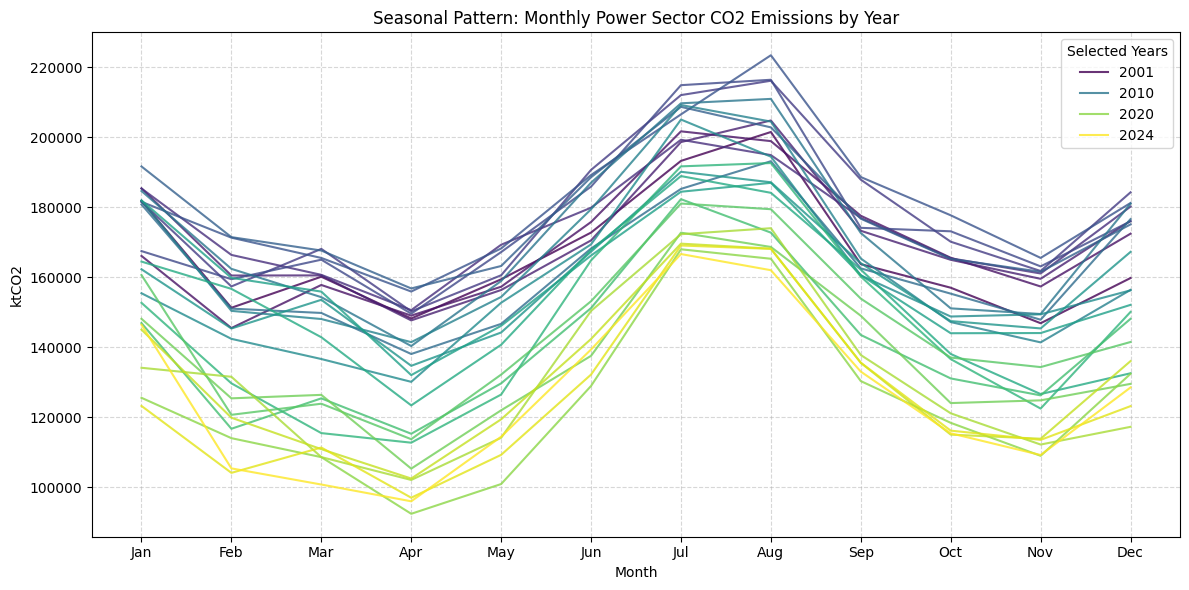

In [135]:
plt.figure(figsize=(12, 6))

ts_emissions['Year'] = ts_emissions.index.year
ts_emissions['Month'] = ts_emissions.index.month

pivot_emissions = ts_emissions.pivot(index='Month', columns='Year', values='Value')

colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_emissions.columns)))
for i, year in enumerate(pivot_emissions.columns):
    label = year if year in [2001, 2010, 2020, 2024] else ""
    plt.plot(pivot_emissions.index, pivot_emissions[year], 
             color=colors[i], marker='', linewidth=1.5, alpha=0.8, label=label)

plt.title('Seasonal Pattern: Monthly Power Sector CO2 Emissions by Year')
plt.ylabel('ktCO2')
plt.xlabel('Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Selected Years')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -0.152613725275687
p-value: 0.9439392482690963
Critical Values:
	1%: -3.4547128138328875
	5%: -2.8722649771800155
	10%: -2.5724850011573914
Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.


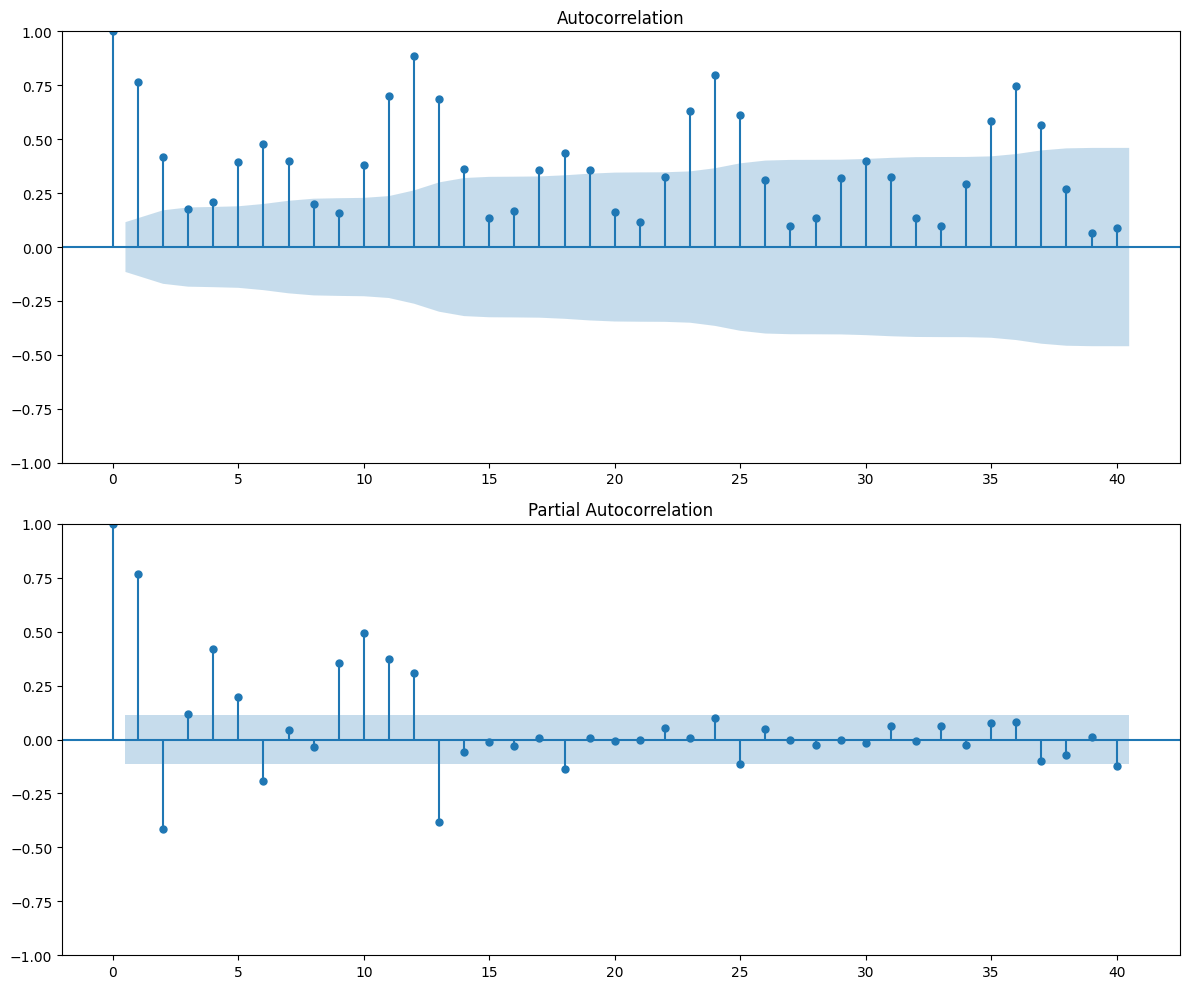

In [136]:
print("\n--- Augmented Dickey-Fuller Test Results ---")
result_emissions = adfuller(ts_emissions['Value'].dropna())
print(f'ADF Statistic: {result_emissions[0]}')
print(f'p-value: {result_emissions[1]}')
print('Critical Values:')
for key, value in result_emissions[4].items():
    print(f'\t{key}: {value}')

if result_emissions[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_emissions['Value'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation')
plot_pacf(ts_emissions['Value'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation')
plt.tight_layout()
plt.show()

ADF Statistic: -4.722425787475618
p-value: 7.635782607979413e-05
Critical Values:
	1%: -3.4554613060274972
	5%: -2.8725931472675046
	10%: -2.5726600403359887
Result: The series is Stationary (Reject Null Hypothesis)


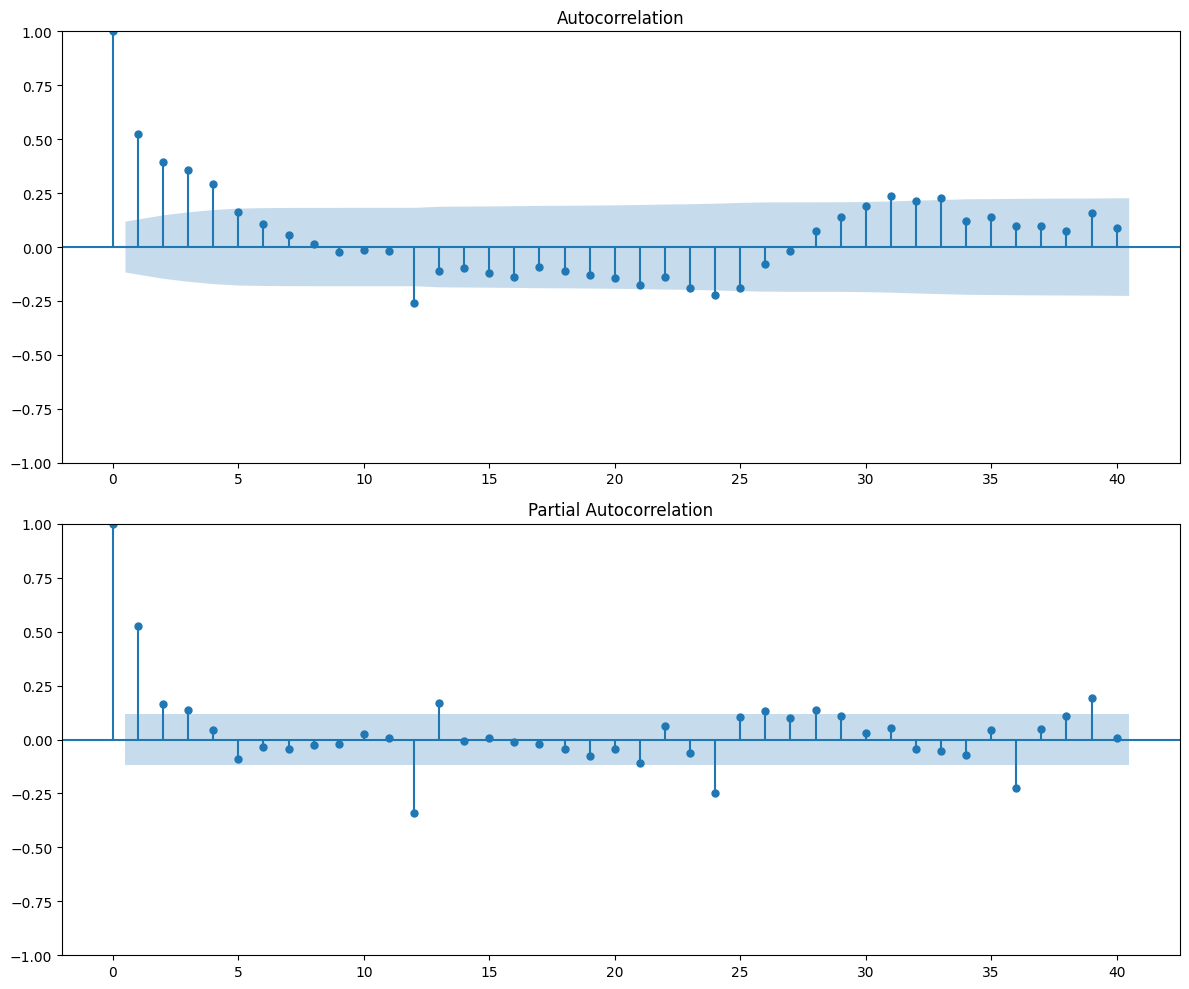

               Value  Year  Month
Date                             
2002-01-01 -15694.37  2002      1
2002-02-01  -5796.67  2002      2
2002-03-01  -2355.98  2002      3
2002-04-01    822.95  2002      4
2002-05-01  -2116.77  2002      5


In [137]:
ts_emissions_seasonal_diff = ts_emissions.copy()
ts_emissions_seasonal_diff['Value'] = ts_emissions['Value'].diff(12)
ts_emissions_seasonal_diff = ts_emissions_seasonal_diff.dropna()

# Test ADF sulla serie differenziata
adf_test_emissions_diff = adfuller(ts_emissions_seasonal_diff['Value'])
print(f'ADF Statistic: {adf_test_emissions_diff[0]}')
print(f'p-value: {adf_test_emissions_diff[1]}')
print('Critical Values:')
for key, value in adf_test_emissions_diff[4].items():
    print(f'\t{key}: {value}')

if adf_test_emissions_diff[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# ACF and PACF Plots sulla serie differenziata
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_emissions_seasonal_diff['Value'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation')
plot_pacf(ts_emissions_seasonal_diff['Value'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation')
plt.tight_layout()
plt.show()

print(ts_emissions_seasonal_diff.head())

Modello SARIMA (senza variabili esogene)

Training data: dal 2001-01-01 al 2022-12-01
Test data: dal 2023-01-01 al 2024-12-01
Training model...
Model trained successfully!
                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  264
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood               -2480.526
Date:                            Tue, 16 Dec 2025   AIC                           4967.052
Time:                                    17:05:52   BIC                           4977.482
Sample:                                01-01-2001   HQIC                          4971.255
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

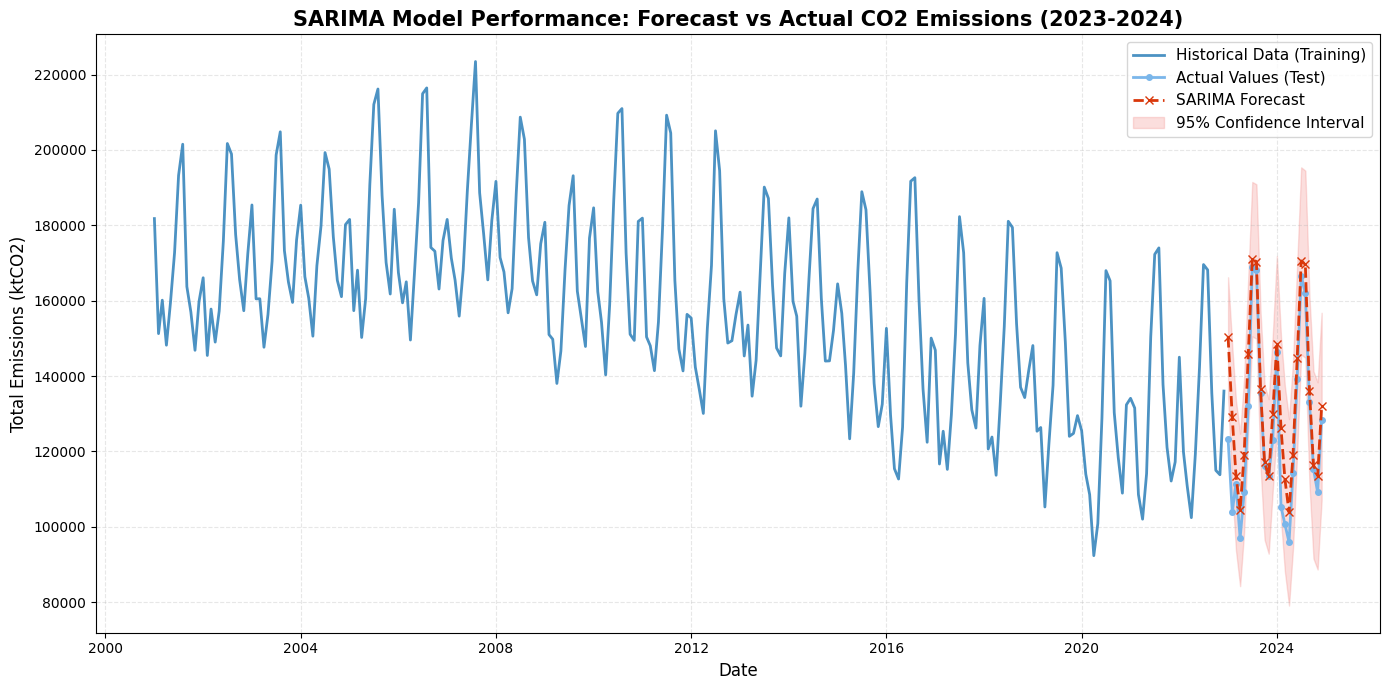

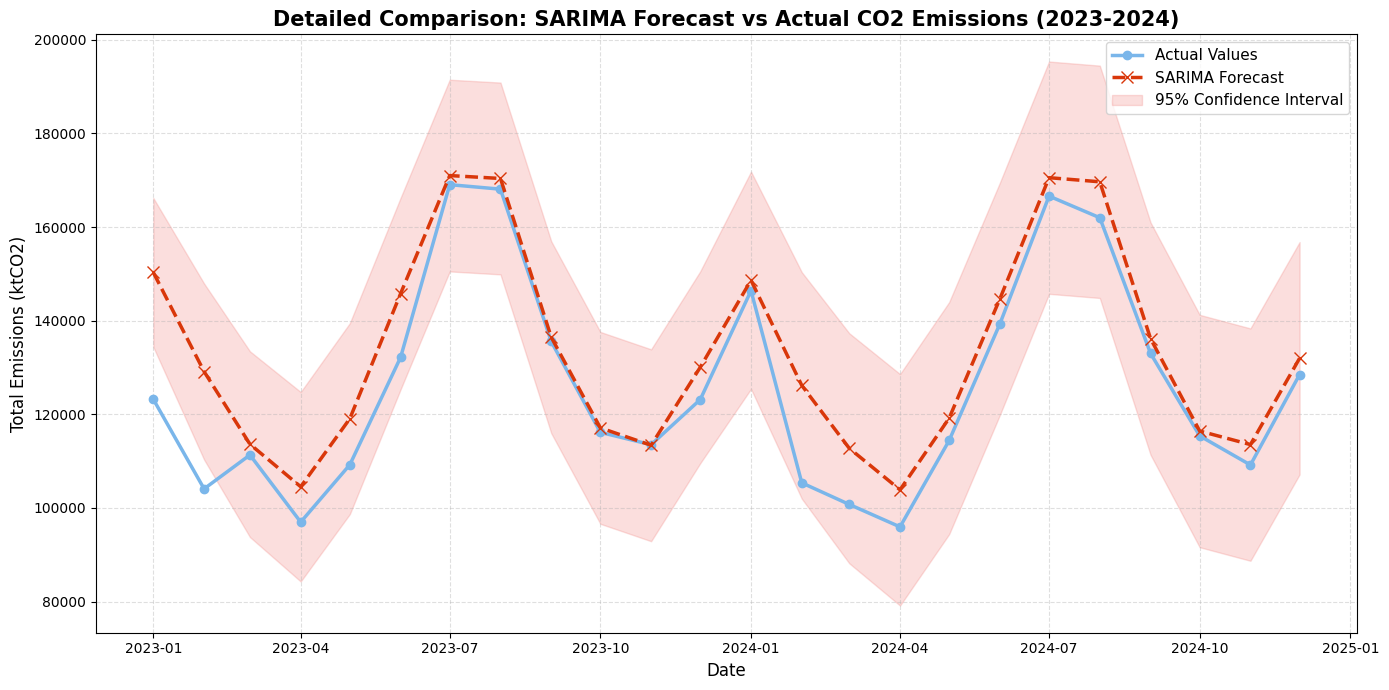


Mean Absolute Percentage Error (MAPE): 6.31%
The model has an average error of 6.31%


In [138]:
train_emissions = ts_emissions.iloc[:-24]
test_emissions = ts_emissions.iloc[-24:]

print(f"Training data: dal {train_emissions.index.min().date()} al {train_emissions.index.max().date()}")
print(f"Test data: dal {test_emissions.index.min().date()} al {test_emissions.index.max().date()}")

# Parametri SARIMA per emissioni
my_order_emissions = (1, 0, 0)              # (p, d, q) - Parte non stagionale
my_seasonal_order_emissions = (1, 1, 0, 12) # (P, D, Q, m) - Parte stagionale (m=12 mesi)

model_emissions_SARIMA = SARIMAX(train_emissions['Value'], 
                          order=my_order_emissions, 
                          seasonal_order=my_seasonal_order_emissions,
                          enforce_stationarity=False,
                          enforce_invertibility=False)

print("Training model...")
model_emissions_fit = model_emissions_SARIMA.fit(disp=False)
print("Model trained successfully!")
print(model_emissions_fit.summary())

forecast_emissions = model_emissions_fit.get_forecast(steps=len(test_emissions))
predicted_emissions = forecast_emissions.predicted_mean
conf_int_emissions = forecast_emissions.conf_int()

plt.figure(figsize=(14, 7))

plt.plot(train_emissions.index, train_emissions['Value'], 
         label='Historical Data (Training)', linewidth=2.0, alpha=0.8) 

plt.plot(test_emissions.index, test_emissions['Value'], 
         label='Actual Values (Test)', 
         color="#7AB6EA", linewidth=2.0, marker='o', markersize=4)

plt.plot(test_emissions.index, predicted_emissions, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='x', markersize=6)

plt.fill_between(test_emissions.index, 
                 conf_int_emissions.iloc[:, 0], 
                 conf_int_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('SARIMA Model Performance: Forecast vs Actual CO2 Emissions (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))

plt.plot(test_emissions.index, test_emissions['Value'], 
         label='Actual Values', 
         color="#7AB6EA", linewidth=2.5, marker='o', markersize=6)

plt.plot(test_emissions.index, predicted_emissions, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='x', markersize=8)

plt.fill_between(test_emissions.index, 
                 conf_int_emissions.iloc[:, 0], 
                 conf_int_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('Detailed Comparison: SARIMA Forecast vs Actual CO2 Emissions (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# Calcolo MAPE
mape_emissions = mean_absolute_percentage_error(test_emissions['Value'], predicted_emissions)
print(f"\nMean Absolute Percentage Error (MAPE): {mape_emissions:.2%}")
print(f"The model has an average error of {mape_emissions:.2%}")


Modello SARIMAX (con variabili esogene)

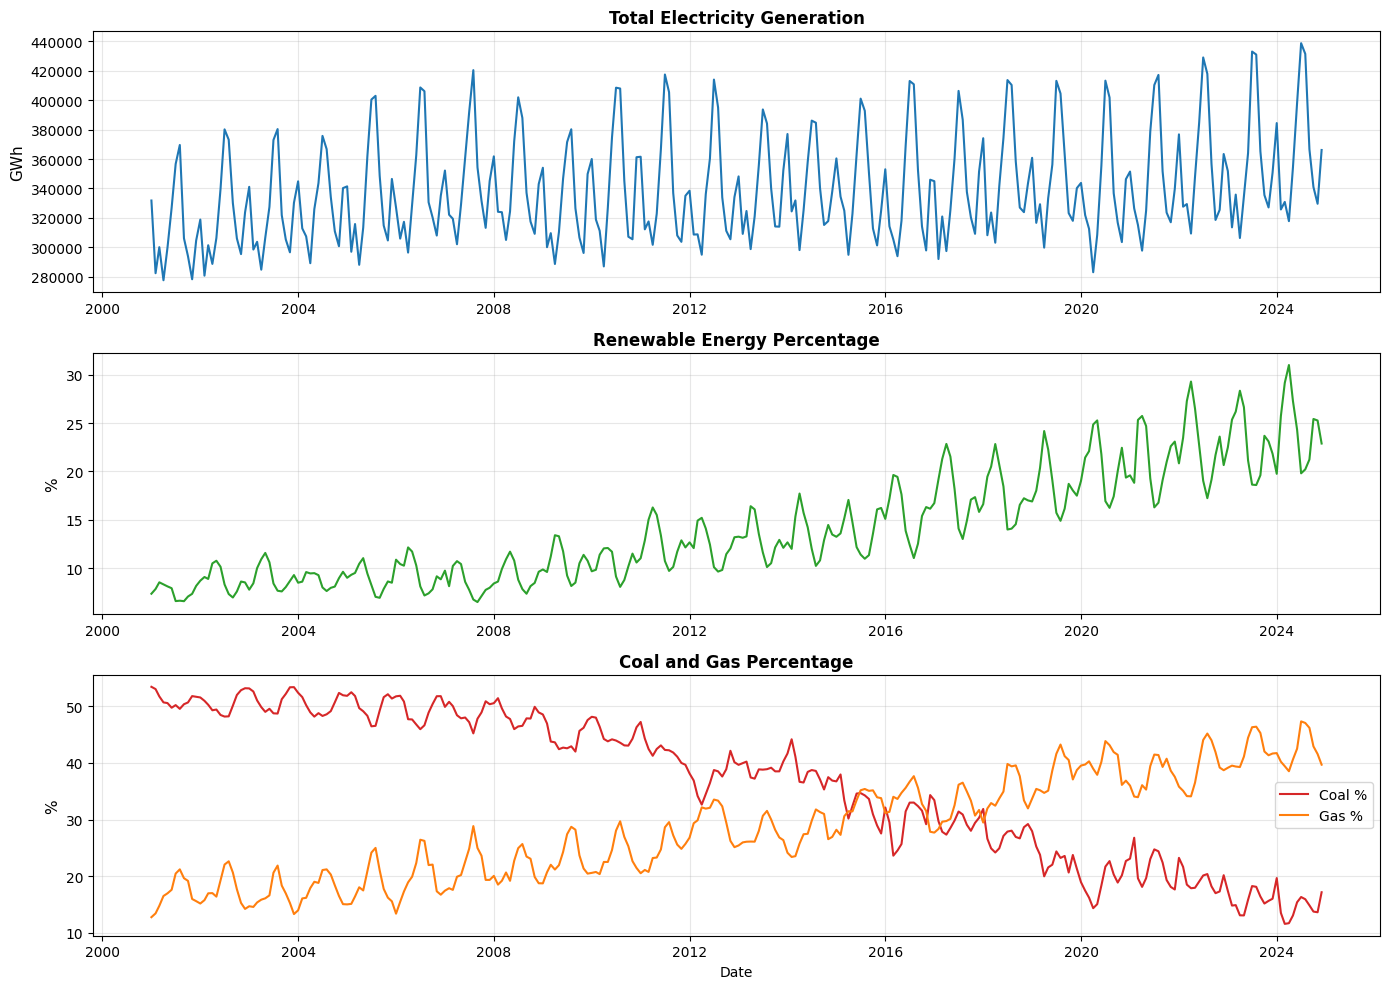

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

df_emissions = pd.read_csv("../data/raw/us_monthly_electricity.csv")
df_emissions['Date'] = pd.to_datetime(df_emissions['Date'])

df_us = df_emissions[
    (df_emissions['State'] == 'US Total') & 
    (df_emissions['Date'].dt.year <= 2024)
].copy()


mask_emissions = (
    (df_us['Category'] == 'Power sector emissions') &
    (df_us['Variable'] == 'Total emissions') &
    (df_us['Unit'] == 'ktCO2')
)

ts_emissions = df_us.loc[mask_emissions, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_emissions = ts_emissions.asfreq('MS')

#Variabile esogena Total Generation
mask_generation = (
    (df_us['Category'] == 'Electricity generation') &
    (df_us['Subcategory'] == 'Total') &
    (df_us['Variable'] == 'Total Generation') &
    (df_us['Unit'] == 'GWh')
)
ts_generation = df_us.loc[mask_generation, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_generation = ts_generation.asfreq('MS')
ts_generation.columns = ['Total_Generation_GWh']

#Variabile esogena %Renewables
mask_renewables_pct = (
    (df_us['Category'] == 'Electricity generation') &
    (df_us['Subcategory'] == 'Aggregate fuel') &
    (df_us['Variable'] == 'Renewables') &
    (df_us['Unit'] == '%')  # ← USA PERCENTUALE GIÀ PRONTA
)
ts_renewables_pct = df_us.loc[mask_renewables_pct, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_renewables_pct = ts_renewables_pct.asfreq('MS')
ts_renewables_pct.columns = ['Renewable_Percentage']

#Variabile esogena %Coal
mask_coal_pct = (
    (df_us['Category'] == 'Electricity generation') &
    (df_us['Subcategory'] == 'Fuel') &
    (df_us['Variable'] == 'Coal') &
    (df_us['Unit'] == '%')  # ← USA PERCENTUALE GIÀ PRONTA
)
ts_coal_pct = df_us.loc[mask_coal_pct, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_coal_pct = ts_coal_pct.asfreq('MS')
ts_coal_pct.columns = ['Coal_Percentage']

#Variabile esogena %Gas
mask_gas_pct = (
    (df_us['Category'] == 'Electricity generation') &
    (df_us['Subcategory'] == 'Fuel') &
    (df_us['Variable'] == 'Gas') &
    (df_us['Unit'] == '%')  # ← USA PERCENTUALE GIÀ PRONTA
)
ts_gas_pct = df_us.loc[mask_gas_pct, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_gas_pct = ts_gas_pct.asfreq('MS')
ts_gas_pct.columns = ['Gas_Percentage']

df_combined = pd.concat([
    ts_emissions['Value'].rename('Total_Emissions_ktCO2'),
    ts_generation['Total_Generation_GWh'],
    ts_renewables_pct['Renewable_Percentage'],
    ts_coal_pct['Coal_Percentage'],
    ts_gas_pct['Gas_Percentage']
], axis=1)

if df_combined.isnull().sum().sum() > 0:
    print("⚠️ ATTENZIONE: Valori mancanti rilevati!")
    print(df_combined.isnull().sum())
    df_combined = df_combined.fillna(method='ffill')
    print("✓ Valori mancanti riempiti con forward fill")

#Grafici variabili esogene
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df_combined.index, df_combined['Total_Generation_GWh'], linewidth=1.5, color='#1f77b4')
axes[0].set_ylabel('GWh', fontsize=11)
axes[0].set_title('Total Electricity Generation', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_combined.index, df_combined['Renewable_Percentage'], linewidth=1.5, color='#2ca02c')
axes[1].set_ylabel('%', fontsize=11)
axes[1].set_title('Renewable Energy Percentage', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_combined.index, df_combined['Coal_Percentage'], linewidth=1.5, color='#d62728', label='Coal %')
axes[2].plot(df_combined.index, df_combined['Gas_Percentage'], linewidth=1.5, color='#ff7f0e', label='Gas %')
axes[2].set_ylabel('%', fontsize=11)
axes[2].set_xlabel('Date')
axes[2].set_title('Coal and Gas Percentage', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TRAIN/TEST SPLIT

Training data: dal 2001-01-01 al 2022-12-01
Test data: dal 2023-01-01 al 2024-12-01

Variabili esogene utilizzate:
  1. Total_Generation_GWh
  2. Renewable_Percentage
  3. Coal_Percentage
  4. Gas_Percentage

Shape train_exog: (264, 4)
Shape test_exog: (24, 4)

Parametri SARIMAX:
  Order (p,d,q): (1, 0, 0)
  Seasonal order (P,D,Q,m): (1, 1, 0, 12)

TRAINING SARIMAX MODEL

Training SARIMAX model with exogenous variables...
✓ Model trained successfully!

                                     SARIMAX Results                                      
Dep. Variable:              Total_Emissions_ktCO2   No. Observations:                  264
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood               -2005.175
Date:                            Tue, 16 Dec 2025   AIC                           4024.350
Time:                                    17:05:54   BIC                           4048.685
Sample:                                01-01-2001   HQIC             

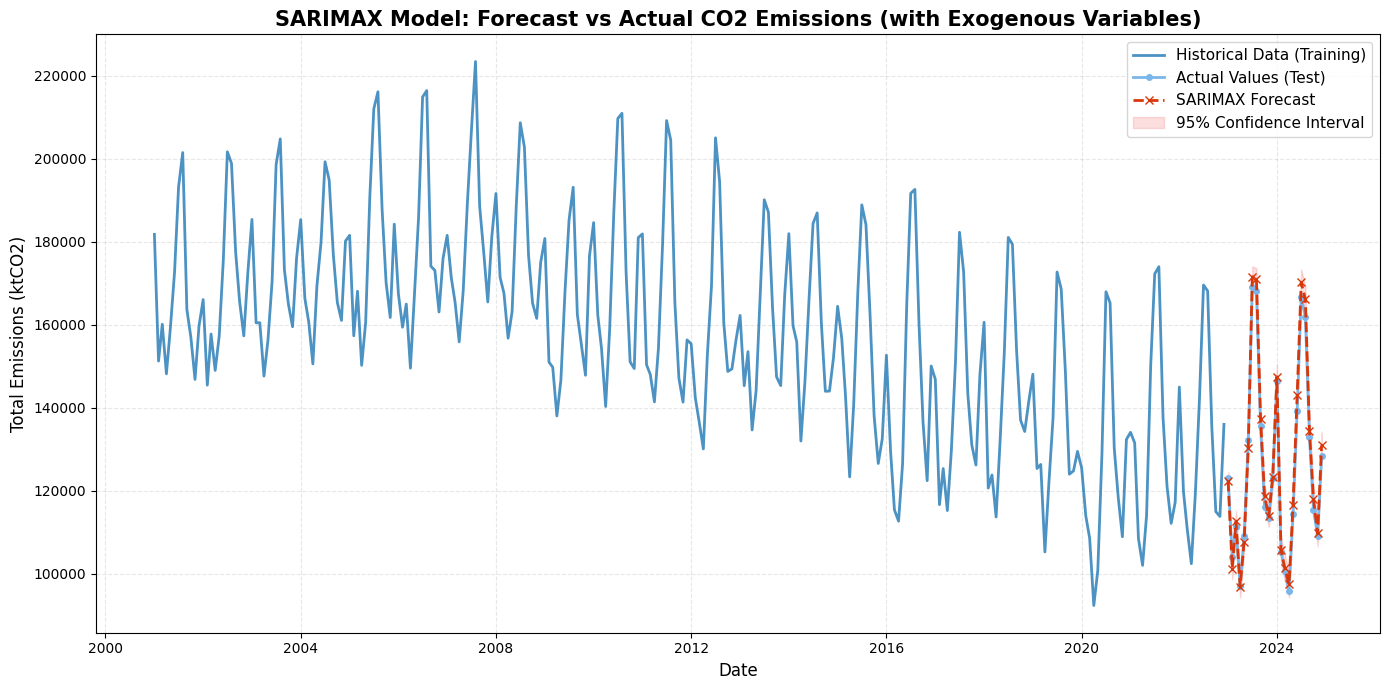

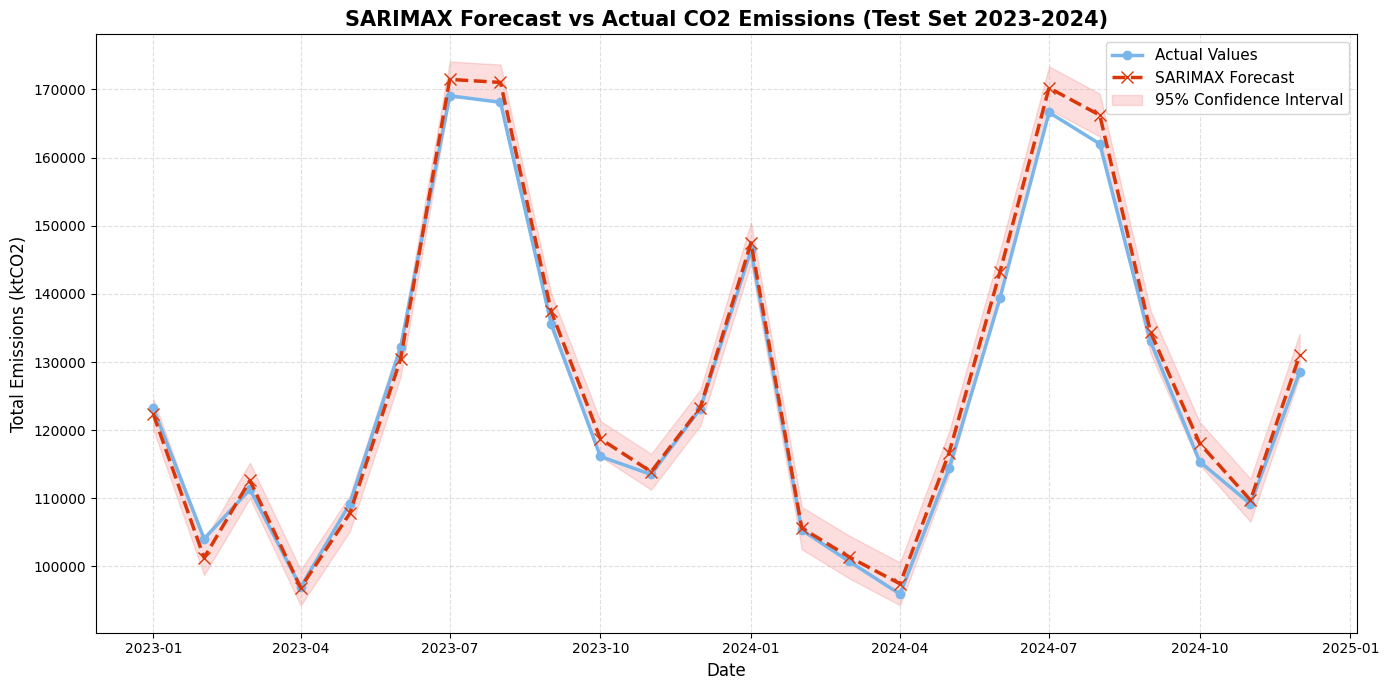

✓ Plots generated successfully!

EXOGENOUS VARIABLES COEFFICIENTS

Variable                             Coefficient    p-value  Significant
----------------------------------------------------------------------
Total_Generation_GWh                      0.5255     0.0000        ✓ Yes
Renewable_Percentage                  -1001.9330     0.0000        ✓ Yes
Coal_Percentage                        1673.8228     0.0000        ✓ Yes
Gas_Percentage                          568.1127     0.0000        ✓ Yes

INTERPRETATION

• Total_Generation_GWh:
  → Increase of 1 GWh generation → +0.53 ktCO2 emissions
  ✓✓✓ Highly significant (p < 0.001)

• Renewable_Percentage:
  → Increase of 1% → REDUCTION of 1001.93 ktCO2
  ✓✓✓ Highly significant (p < 0.001)

• Coal_Percentage:
  → Increase of 1% → INCREASE of 1673.82 ktCO2
  ✓✓✓ Highly significant (p < 0.001)

• Gas_Percentage:
  → Increase of 1% → INCREASE of 568.11 ktCO2
  ✓✓✓ Highly significant (p < 0.001)

SARIMAX ANALYSIS COMPLETED!


In [140]:
print("\n" + "="*70)
print("TRAIN/TEST SPLIT")
print("="*70)

train_size = len(df_combined) - 24


train_emissions = df_combined['Total_Emissions_ktCO2'].iloc[:train_size]
test_emissions = df_combined['Total_Emissions_ktCO2'].iloc[train_size:]

exog_cols = ['Total_Generation_GWh', 'Renewable_Percentage', 'Coal_Percentage', 'Gas_Percentage']

train_exog = df_combined[exog_cols].iloc[:train_size]
test_exog = df_combined[exog_cols].iloc[train_size:]

print(f"\nTraining data: dal {train_emissions.index.min().date()} al {train_emissions.index.max().date()}")
print(f"Test data: dal {test_emissions.index.min().date()} al {test_emissions.index.max().date()}")
print(f"\nVariabili esogene utilizzate:")
for i, col in enumerate(exog_cols, 1):
    print(f"  {i}. {col}")
print(f"\nShape train_exog: {train_exog.shape}")
print(f"Shape test_exog: {test_exog.shape}")

#Parametri modello SARIMAX
my_order_emissions = (1, 0, 0)
my_seasonal_order_emissions = (1, 1, 0, 12)

print(f"\nParametri SARIMAX:")
print(f"  Order (p,d,q): {my_order_emissions}")
print(f"  Seasonal order (P,D,Q,m): {my_seasonal_order_emissions}")

print("\n" + "="*70)
print("TRAINING SARIMAX MODEL")
print("="*70)

model_emissions_SARIMAX = SARIMAX(
    train_emissions,
    exog=train_exog,
    order=my_order_emissions, 
    seasonal_order=my_seasonal_order_emissions,
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("\nTraining SARIMAX model with exogenous variables...")
model_emissions_fit = model_emissions_SARIMAX.fit(disp=False)
print("✓ Model trained successfully!")
print("\n" + "="*70)
print(model_emissions_fit.summary())
print("="*70)

print("\n" + "="*70)
print("FORECAST")
print("="*70)

forecast_emissions = model_emissions_fit.get_forecast(
    steps=len(test_emissions),
    exog=test_exog
)

predicted_emissions = forecast_emissions.predicted_mean
conf_int_emissions = forecast_emissions.conf_int()

print(f"\n✓ Forecast generato per {len(test_emissions)} mesi")

mae_emissions = mean_absolute_error(test_emissions, predicted_emissions)
rmse_emissions = np.sqrt(mean_squared_error(test_emissions, predicted_emissions))
mape_emissions = mean_absolute_percentage_error(test_emissions, predicted_emissions)
r2_emissions = r2_score(test_emissions, predicted_emissions)

print("\n" + "="*70)
print("SARIMAX MODEL PERFORMANCE (Test Set 2023-2024)")
print("="*70)
print(f"MAE (Mean Absolute Error):          {mae_emissions:>12,.2f} ktCO2")
print(f"RMSE (Root Mean Squared Error):    {rmse_emissions:>12,.2f} ktCO2")
print(f"MAPE (Mean Absolute % Error):      {mape_emissions:>12.2%}")
print(f"R² Score:                           {r2_emissions:>12.4f}")
print("="*70)
print(f"\n✓ The SARIMAX model has an average error of {mape_emissions:.2%}")

print("\n" + "="*70)
print("GENERATING PLOTS")
print("="*70)

# Grafico 1: TRAIN + TEST + FORECAST
plt.figure(figsize=(14, 7))

plt.plot(train_emissions.index, train_emissions, 
         label='Historical Data (Training)', linewidth=2.0, alpha=0.8) 

plt.plot(test_emissions.index, test_emissions, 
         label='Actual Values (Test)', 
         color="#7AB6EA", linewidth=2.0, marker='o', markersize=4)

plt.plot(test_emissions.index, predicted_emissions, 
         label='SARIMAX Forecast',
         color="#D9370A", linestyle='--', linewidth=2.0, marker='x', markersize=6)

plt.fill_between(test_emissions.index, 
                 conf_int_emissions.iloc[:, 0], 
                 conf_int_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('SARIMAX Model: Forecast vs Actual CO2 Emissions (with Exogenous Variables)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Grafico 2: ZOOM SU TEST SET
plt.figure(figsize=(14, 7))

plt.plot(test_emissions.index, test_emissions, 
         label='Actual Values', 
         color="#7AB6EA", linewidth=2.5, marker='o', markersize=6)

plt.plot(test_emissions.index, predicted_emissions, 
         label='SARIMAX Forecast',
         color="#D9370A", linestyle='--', linewidth=2.5, marker='x', markersize=8)

plt.fill_between(test_emissions.index, 
                 conf_int_emissions.iloc[:, 0], 
                 conf_int_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('SARIMAX Forecast vs Actual CO2 Emissions (Test Set 2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

print("✓ Plots generated successfully!")

print("\n" + "="*70)
print("EXOGENOUS VARIABLES COEFFICIENTS")
print("="*70)

params = model_emissions_fit.params
pvalues = model_emissions_fit.pvalues

print(f"\n{'Variable':<35} {'Coefficient':>12} {'p-value':>10} {'Significant':>12}")
print("-" * 70)

for var in exog_cols:
    if var in params.index:
        coef = params[var]
        pval = pvalues[var]
        sig = "✓ Yes" if pval < 0.05 else "✗ No"
        print(f"{var:<35} {coef:>12.4f} {pval:>10.4f} {sig:>12}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

for var in exog_cols:
    if var in params.index:
        coef = params[var]
        pval = pvalues[var]
        
        print(f"\n• {var}:")
        
        if 'Generation' in var:
            print(f"  → Increase of 1 GWh generation → {coef:+.2f} ktCO2 emissions")
        elif 'Percentage' in var:
            if coef < 0:
                print(f"  → Increase of 1% → REDUCTION of {abs(coef):.2f} ktCO2")
            else:
                print(f"  → Increase of 1% → INCREASE of {coef:.2f} ktCO2")
        
        if pval < 0.001:
            print(f"  ✓✓✓ Highly significant (p < 0.001)")
        elif pval < 0.01:
            print(f"  ✓✓ Very significant (p < 0.01)")
        elif pval < 0.05:
            print(f"  ✓ Significant (p < 0.05)")
        else:
            print(f"  ✗ NOT statistically significant (p = {pval:.4f})")

print("\n" + "="*70)
print("SARIMAX ANALYSIS COMPLETED!")
print("="*70)


Però per fare il forecast sul futuro dovrei sapere i valori delle variabili esogene nel futuro, ma non li ho, quindi si usa il modello SARIMA

Training model on full dataset...
Model trained successfully!

=== Future Forecasts - CO2 Emissions ===
            Predicted_Value    Lower_Bound    Upper_Bound
Date                                                     
2025-01-01    137858.387636  121397.234099  154319.541173
2025-02-01    105027.989223   85780.936461  124275.041986
2025-03-01    104856.740836   84683.234700  125030.246972
2025-04-01     96393.057025   75889.930357  116896.183692
2025-05-01    112470.380095   91847.563863  133093.196328
2025-06-01    136635.648487  115969.065283  157302.231692
2025-07-01    167562.346123  146879.718250  188244.973995
2025-08-01    164326.843266  143638.328132  185015.358400
2025-09-01    133986.042409  113295.366339  154676.718479
2025-10-01    115677.706045   94986.236700  136369.175389
2025-11-01    110821.569780   90129.809212  131513.330347
2025-12-01    126459.857479  105767.989998  147151.724960
2026-01-01    141109.189774  118019.744983  164198.634566
2026-02-01    105151.88919

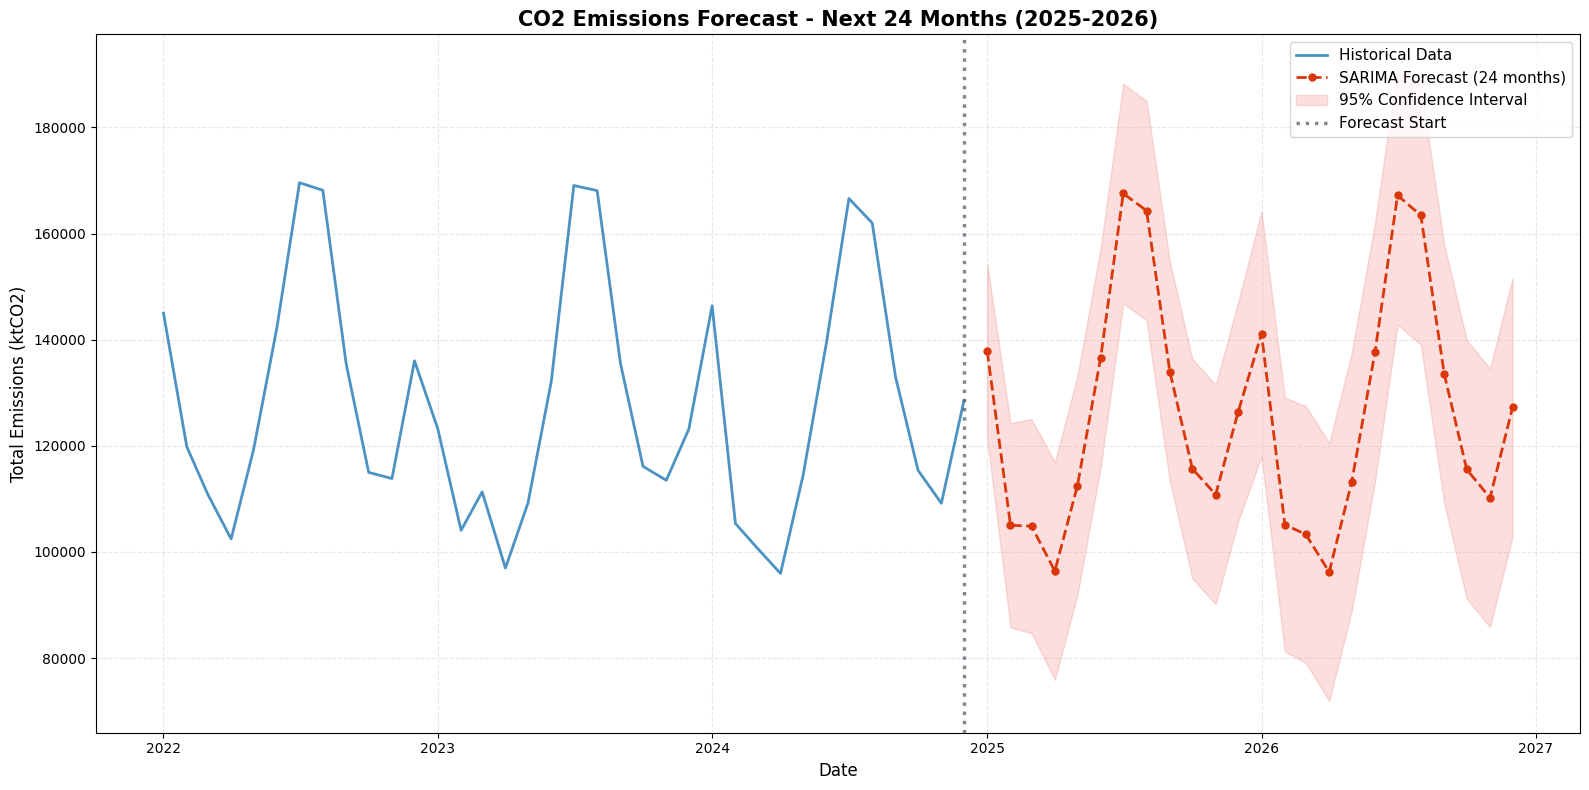

In [141]:
full_emissions = ts_emissions['Value']

my_order_emissions = (1, 0, 0)
my_seasonal_order_emissions = (1, 1, 0, 12)

model_full_emissions = SARIMAX(full_emissions, 
                               order=my_order_emissions, 
                               seasonal_order=my_seasonal_order_emissions,
                               enforce_stationarity=False,
                               enforce_invertibility=False)

print("Training model on full dataset...")
model_full_emissions_fit = model_full_emissions.fit(disp=False)
print("Model trained successfully!")

n_months = 24  # Modify to forecast more or fewer months

forecast_future_emissions = model_full_emissions_fit.get_forecast(steps=n_months)
predicted_future_emissions = forecast_future_emissions.predicted_mean
conf_int_future_emissions = forecast_future_emissions.conf_int()

last_date_emissions = ts_emissions.index[-1]
future_dates_emissions = pd.date_range(start=last_date_emissions + pd.DateOffset(months=1), 
                                       periods=n_months, 
                                       freq='MS')

forecast_emissions_df = pd.DataFrame({
    'Date': future_dates_emissions,
    'Predicted_Value': predicted_future_emissions.values,
    'Lower_Bound': conf_int_future_emissions.iloc[:, 0].values,
    'Upper_Bound': conf_int_future_emissions.iloc[:, 1].values
})
forecast_emissions_df.set_index('Date', inplace=True)

print("\n=== Future Forecasts - CO2 Emissions ===")
print(forecast_emissions_df)

plt.figure(figsize=(16, 8))

historical_emissions = ts_emissions.iloc[-36:]
plt.plot(historical_emissions.index, historical_emissions['Value'], 
         label='Historical Data', linewidth=2.0, alpha=0.8)

plt.plot(future_dates_emissions, predicted_future_emissions, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='o', markersize=5)

plt.fill_between(future_dates_emissions, 
                 conf_int_future_emissions.iloc[:, 0], 
                 conf_int_future_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.axvline(x=ts_emissions.index[-1], color="#4A5866", 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title(f'CO2 Emissions Forecast - Next {n_months} Months (2025-2026)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


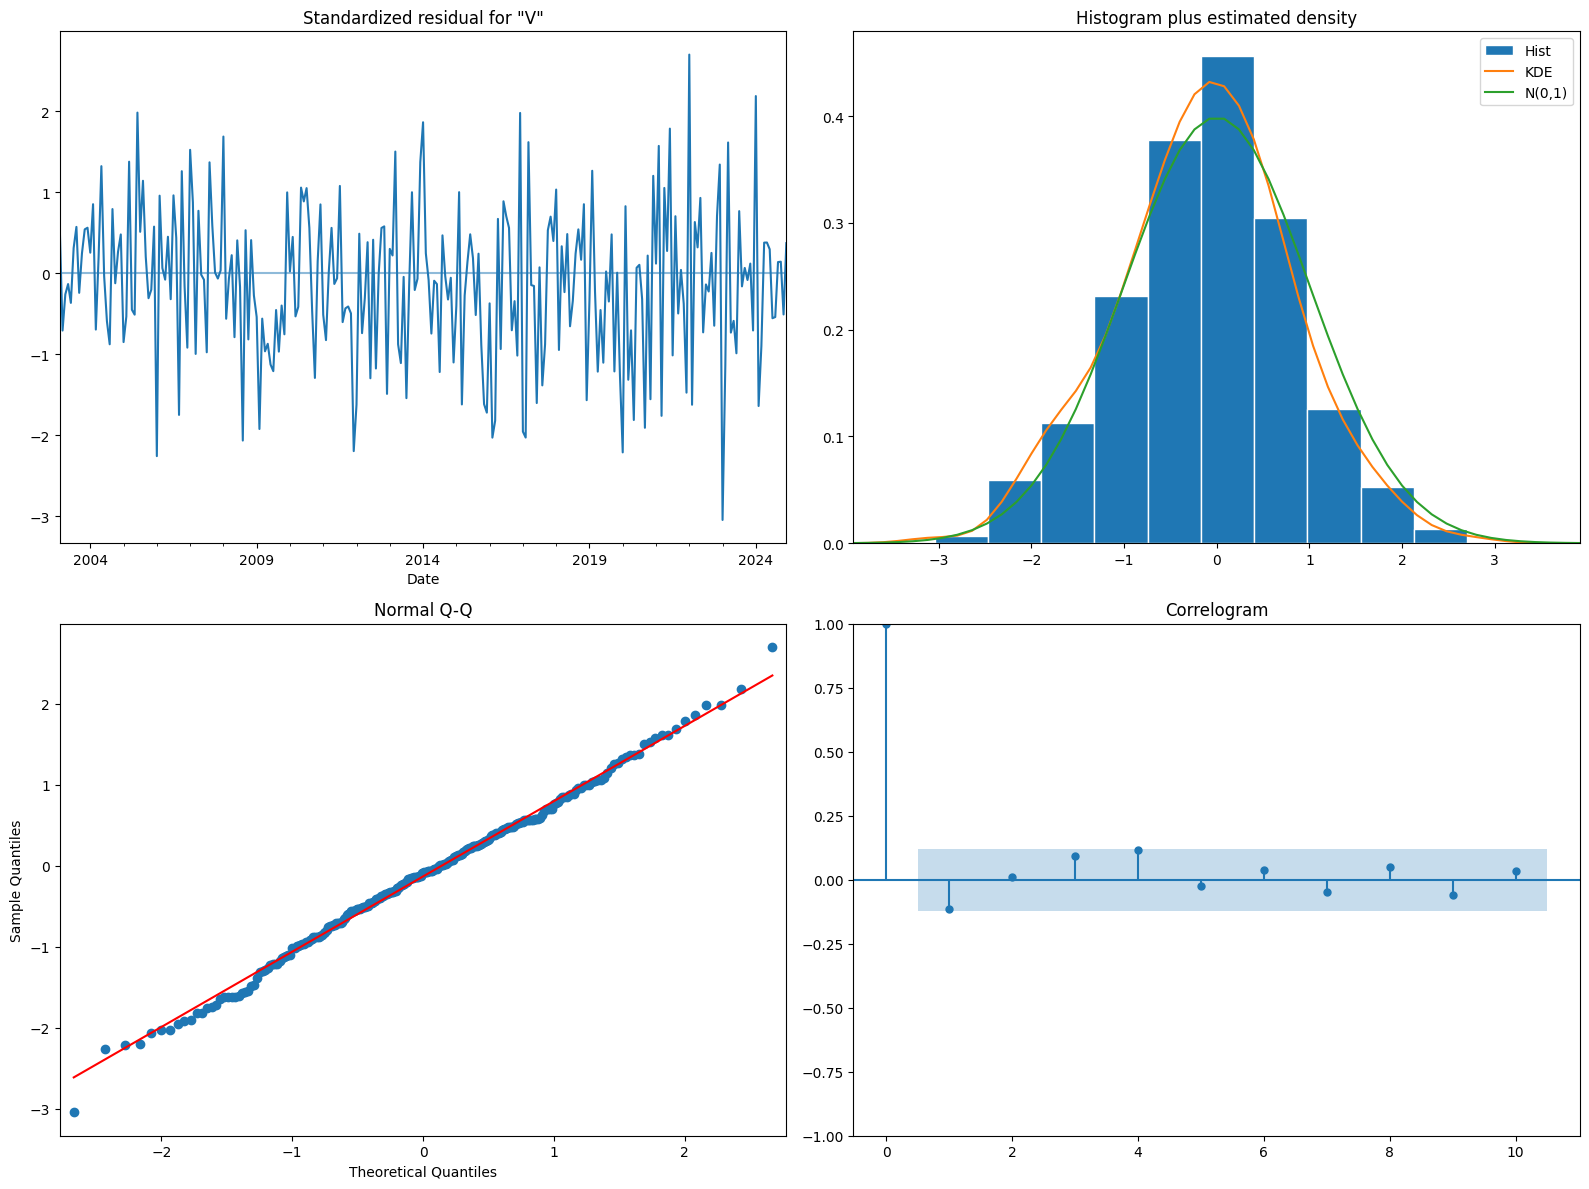

In [142]:
# Diagnostica completa del modello
fig = model_full_emissions_fit.plot_diagnostics(figsize=(16, 12))
plt.tight_layout()
plt.show()

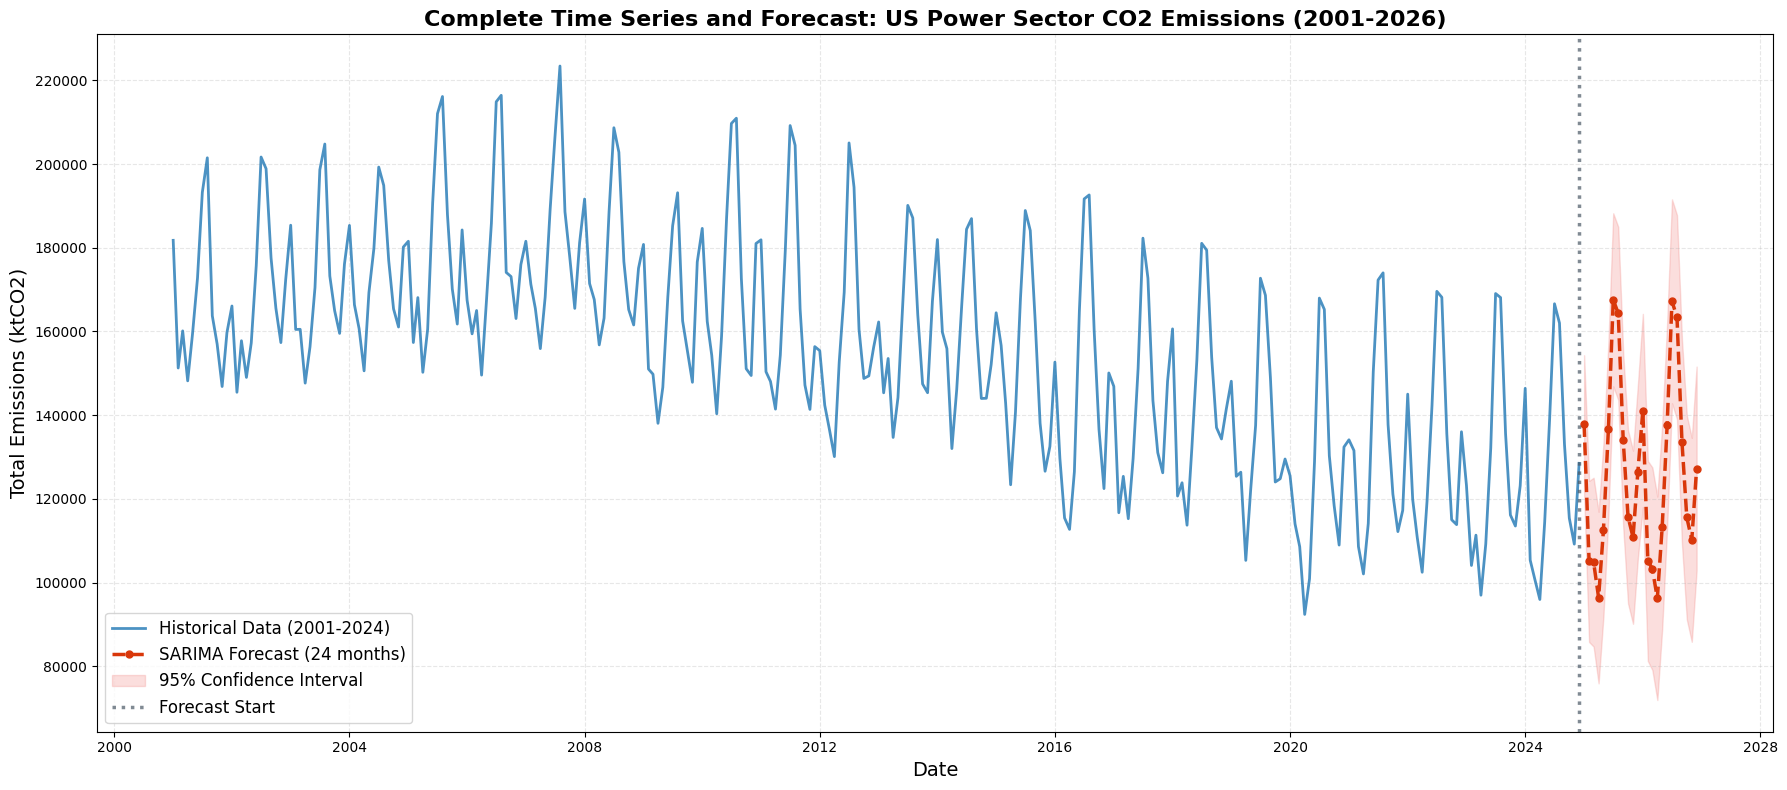

In [143]:
plt.figure(figsize=(18, 8))

plt.plot(ts_emissions.index, ts_emissions['Value'], 
         label='Historical Data (2001-2024)', linewidth=2.0, alpha=0.8)

plt.plot(future_dates_emissions, predicted_future_emissions, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='o', markersize=5)

plt.fill_between(future_dates_emissions, 
                 conf_int_future_emissions.iloc[:, 0], 
                 conf_int_future_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, label='95% Confidence Interval')

plt.axvline(x=ts_emissions.index[-1], color='#4A5866', 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title('Complete Time Series and Forecast: US Power Sector CO2 Emissions (2001-2026)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Emissions (ktCO2)', fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
